# LIF Network Simulation
## Clustered Network with Leaky Integrate-and-Fire Neurons

This notebook implements a clustered LIF network model that can run in either spontaneous-firing or externally stimulated modes.

**Key Features:**
- Clustered recurrent connectivity with excitatory, inhibitory, and hub neurons
- Optional periodic cluster stimulation for burst experiments
- Spontaneous low-rate firing when stimulation is disabled
- Resampled output saved at 10 Hz for acquisition-style comparison
- Session-based save/load workflow under the LIF data folder

## Part 0: Imports

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import os
import sys
import random
from datetime import datetime
import json
from pathlib import Path

# # Set random seeds for reproducibility
# np.random.seed(42)
# random.seed(42)

## Part 1: LIF Neuron Model and Basic Functions

In [40]:
class LIFNeuron:
    """
    Leaky Integrate-and-Fire neuron model with spike-frequency adaptation (SFA)
    
    Based on cortical neuron properties:
    - Excitatory (pyramidal): tau_m ~ 20ms, lower excitability, STRONG adaptation
    - Inhibitory (interneurons): tau_m ~ 10ms, higher excitability, WEAK adaptation
    
    Target: NEAR-CRITICAL network — sparse inter-burst firing, stimulus-driven bursts
    
    Modified for stimulus-driven bursting:
    - v_rest = -61.5 mV (11.5mV gap to threshold)
    - noise_sigma = 1.1 mV (moderate inter-burst activity)
    - Stronger adaptation to prevent aftershock bursts
    """
    def __init__(self, neuron_id, is_inhibitory=False):
        self.neuron_id = neuron_id
        self.is_inhibitory = is_inhibitory
        
        # LIF parameters - biologically realistic values
        if is_inhibitory:
            self.tau_m = 10.0      # Faster for interneurons (ms)
            self.v_thresh = -50.0  # Threshold
            # Inhibitory neurons have very weak adaptation
            self.adaptation_increment = 0.003  # nA per spike
            self.tau_adaptation = 40.0         # ms - fast decay
        else:
            self.tau_m = 20.0      # Slower for pyramidal cells (ms)
            self.v_thresh = -50.0  # Standard threshold
            # Excitatory neurons: stronger adaptation to prevent aftershock bursts
            self.adaptation_increment = 0.025  # nA per spike (was 0.015) - stronger burst termination
            self.tau_adaptation = 300.0        # ms (was 150.0) - slower recovery prevents re-firing
        
        # Common parameters - TUNED for near-critical dynamics
        self.v_rest = -61.5    # Resting potential (mV) - 11.5mV from threshold
        self.v_reset = -70.0   # Reset after spike (mV)
        self.v_floor = -80.0   # Minimum voltage (mV) - prevents unrealistic hyperpolarization
        self.R_m = 100.0       # Membrane resistance (MOhm)
        self.tau_ref = 2.0     # Absolute refractory period (ms)
        self.noise_sigma = 1.05 # Noise for variability (mV) - moderate inter-burst activity
        
        # State variables
        self.v = self.v_rest + np.random.uniform(-2, 2)
        self.t_last_spike = -np.inf
        self.spike_times = []
        
        # Synaptic current
        self.i_syn = 0.0
        self.i_ext = 0.0
        
        # Spike-frequency adaptation current (inhibitory)
        self.i_adapt = 0.0
    
    def update(self, t, dt):
        """
        Update neuron state for one time step using Euler integration
        """
        spiked = False
        
        # Decay adaptation current
        self.i_adapt *= np.exp(-dt / self.tau_adaptation)
        
        # Check if in refractory period
        if t - self.t_last_spike < self.tau_ref:
            self.v = self.v_reset
            return False
        
        # Add noise (scaled by sqrt(dt) for proper stochastic integration)
        noise = np.random.normal(0, self.noise_sigma) * np.sqrt(dt)
        
        # Update membrane potential (adaptation current is inhibitory, so subtract it)
        # dV/dt = (V_rest - V + R_m * (I_syn + I_ext - I_adapt)) / tau_m
        current_term = self.R_m * (self.i_syn + self.i_ext - self.i_adapt)
        dv = ((self.v_rest - self.v) + current_term) * dt / self.tau_m + noise
        self.v += dv
        
        # Enforce voltage floor (biological realism)
        if self.v < self.v_floor:
            self.v = self.v_floor
        
        # Check for spike
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.t_last_spike = t
            self.spike_times.append(t)
            # Increase adaptation current after each spike
            self.i_adapt += self.adaptation_increment
            spiked = True
        
        return spiked
    
    def reset_state(self):
        """Reset neuron to initial state"""
        self.v = self.v_rest + np.random.uniform(-2, 2)
        self.t_last_spike = -np.inf
        self.spike_times = []
        self.i_syn = 0.0
        self.i_ext = 0.0
        self.i_adapt = 0.0

In [41]:
class ExpSynapse:
    """
    Exponential synapse model (current-based, simplified)
    
    Uses current injection rather than conductance for simpler dynamics.
    The synaptic current decays exponentially after each presynaptic spike.
    """
    def __init__(self, pre_neuron_id, post_neuron, weight, is_inhibitory=False, delay=1.0):
        self.pre_neuron_id = pre_neuron_id
        self.post_neuron = post_neuron
        self.weight = weight  # Synaptic weight (nA) - direct current injection
        self.is_inhibitory = is_inhibitory
        self.delay = delay  # Synaptic delay (ms)
        
        # Synapse time constants (biologically realistic)
        if is_inhibitory:
            self.tau = 10.0  # GABA synapses: slower decay (~10 ms)
        else:
            self.tau = 3.0   # AMPA synapses: fast decay (~2-5 ms)
        
        # State variable
        self.i_syn = 0.0  # Current synaptic current contribution (nA)
        self.pending_spikes = []  # Queue of delayed spikes
    
    def receive_spike(self, t):
        """Add spike to queue with delay"""
        self.pending_spikes.append(t + self.delay)
    
    def update(self, t, dt):
        """
        Update synaptic current
        
        Args:
            t: Current time (ms)
            dt: Time step (ms)
        
        Returns:
            float: Synaptic current contribution (nA)
        """
        # Check for arriving spikes
        while self.pending_spikes and self.pending_spikes[0] <= t:
            self.pending_spikes.pop(0)
            # Add current pulse (positive for exc, negative for inh)
            if self.is_inhibitory:
                self.i_syn -= abs(self.weight)  # Negative current
            else:
                self.i_syn += abs(self.weight)  # Positive current
        
        # Decay synaptic current exponentially
        self.i_syn *= np.exp(-dt / self.tau)
        
        return self.i_syn

In [42]:
class NetworkWeightParameters:
    """
    Parameters for synaptic weights (current in nA)
    
    Target: Near-critical network â€” prevent auto-bursting but keep inter-burst firing
    With R_m=100 MOhm, v_rest=-62mV, v_thresh=-50mV (12mV gap)
    
    TUNED: Reduced excitation (~40-45%) to prevent auto-bursting,
           increased inhibition (~12-15%) for faster burst termination
    """
    def __init__(self):
        # Excitatory weights (nA) - reduced to prevent auto-bursting
        self.within_exc_range = (0.25, 0.45)    # Within-cluster (was 0.45, 0.70) ~40% reduction
        self.between_exc_range = (0.20, 0.35)   # Between-cluster (was 0.40, 0.60) ~45% reduction
        
        # Inhibitory weights (nA) - slightly increased for burst termination
        self.within_inh_range = (0.35, 0.55)    # Local inhibition (was 0.30, 0.50) ~15% increase
        self.between_inh_range = (0.28, 0.45)   # Distant inhibition (was 0.25, 0.40) ~12% increase
        
        # Weight distribution
        self.use_lognormal = True
        self.lognormal_sigma = 0.5

# PresynapticParameters class removed - no background input in this model

## Part 2: Network Creation Functions

In [43]:
def generate_non_overlapping_cluster_positions(num_clusters, cluster_radius, space_size=50):
    """
    Generate non-overlapping cluster positions in 2D space
    """
    positions = []
    min_distance = cluster_radius * 2.0  # Reduced from 2.5 to 2.0 for tighter packing
    
    max_attempts = 1000
    clusters_placed = 0
    for _ in range(num_clusters):
        placed = False
        for attempt in range(max_attempts):
            pos = np.random.uniform(0, space_size, 2)
            
            if not positions:
                positions.append(pos)
                clusters_placed += 1
                placed = True
                break
            
            distances = np.sqrt(np.sum((np.array(positions) - pos)**2, axis=1))
            if np.all(distances >= min_distance):
                positions.append(pos)
                clusters_placed += 1
                placed = True
                break
        
        if not placed:
            print(f"Warning: Could only place {clusters_placed} out of {num_clusters} clusters in space_size={space_size}")
            break
    
    return np.array(positions)

def calculate_lognormal_params(mean_val, sigma):
    """Calculate lognormal distribution parameters"""
    mu = np.log(mean_val / np.sqrt(1 + (sigma / mean_val)**2))
    sigma_log = np.sqrt(np.log(1 + (sigma / mean_val)**2))
    return mu, sigma_log

def generate_lognormal_weight(mean_val, sigma):
    """Generate weight from lognormal distribution"""
    mu, sigma_log = calculate_lognormal_params(mean_val, sigma)
    return np.random.lognormal(mu, sigma_log)

def get_connection_weight(pre_cluster, post_cluster, is_inhibitory, weight_params):
    """Get synaptic weight based on cluster relationship"""
    if pre_cluster == post_cluster:
        if is_inhibitory:
            weight_range = weight_params.within_inh_range
        else:
            weight_range = weight_params.within_exc_range
    else:
        if is_inhibitory:
            weight_range = weight_params.between_inh_range
        else:
            weight_range = weight_params.between_exc_range
    
    if weight_params.use_lognormal:
        mean_val = np.mean(np.abs(weight_range))
        weight = generate_lognormal_weight(mean_val, weight_params.lognormal_sigma)
        weight = np.clip(weight, np.min(np.abs(weight_range)), np.max(np.abs(weight_range)))
        if is_inhibitory:
            weight = -weight
    else:
        weight = np.random.uniform(*weight_range)
    
    return weight

def calculate_connection_probability(distance, same_cluster, 
                                    within_cluster_prob=0.5,
                                    between_cluster_prob=0.1,
                                    max_distance=3.0,
                                    distance_decay='gaussian',
                                    decay_sigma=1.0):
    """Calculate connection probability based on distance and cluster membership"""
    base_prob = within_cluster_prob if same_cluster else between_cluster_prob
    
    if distance > max_distance:
        return 0.0
    
    if distance_decay == 'gaussian':
        distance_factor = np.exp(-(distance**2) / (2 * decay_sigma**2))
    elif distance_decay == 'exponential':
        distance_factor = np.exp(-distance / decay_sigma)
    else:
        distance_factor = 1.0
    
    return base_prob * distance_factor

def designate_hub_neurons(cluster_neuron_groups, hub_fraction=0.1):
    """
    Designate a fraction of neurons in each cluster as hub neurons.
    
    Hub neurons are highly connected neurons that bridge clusters and
    drive burst propagation. They make up ~5-15% of neurons but account
    for a large share of total connectivity.
    
    Parameters
    ----------
    cluster_neuron_groups : list of lists
        Each sublist contains global neuron IDs for one cluster.
    hub_fraction : float
        Fraction of neurons per cluster to designate as hubs (0.05-0.15).
    
    Returns
    -------
    hub_neuron_ids : list of int
        Global neuron IDs of all hub neurons.
    hub_cluster_map : dict
        Maps global neuron ID -> cluster index for each hub.
    """
    hub_neuron_ids = []
    hub_cluster_map = {}
    
    for cluster_idx, neuron_ids in enumerate(cluster_neuron_groups):
        n_hubs = max(1, int(len(neuron_ids) * hub_fraction))
        hub_local_indices = np.random.choice(len(neuron_ids), n_hubs, replace=False)
        
        for local_idx in hub_local_indices:
            global_id = neuron_ids[local_idx]
            hub_neuron_ids.append(global_id)
            hub_cluster_map[global_id] = cluster_idx
    
    return hub_neuron_ids, hub_cluster_map

def add_hub_connections(neurons, hub_neuron_ids, hub_cluster_map, 
                       cluster_neuron_groups, cluster_assignments,
                       neuron_positions, synapses, connections_list,
                       weight_params, max_connection_distance=8.0,
                       hub_between_prob=0.4, hub_weight_scale=1.5,
                       hub_reciprocal_factor=2.0):
    """
    Add elevated inter-cluster connections for hub neurons.
    
    Called AFTER base network connectivity is created. Adds additional
    between-cluster connections for designated hub neurons with higher
    probability and scaled weights.
    
    Parameters
    ----------
    neurons : list of LIFNeuron
        All neurons in the network.
    hub_neuron_ids : list of int
        Global IDs of hub neurons.
    hub_cluster_map : dict
        Maps hub global ID -> cluster index.
    cluster_neuron_groups : list of lists
        Neuron IDs grouped by cluster.
    cluster_assignments : np.ndarray
        Cluster ID for each neuron.
    neuron_positions : np.ndarray
        (n_neurons, 2) positions.
    synapses : list of ExpSynapse
        Existing synapse list to append to.
    connections_list : list
        Existing connections list to append to (list of [pre, post, weight, type]).
    weight_params : NetworkWeightParameters
        Weight ranges for the network.
    max_connection_distance : float
        Maximum distance for hub connections.
    hub_between_prob : float
        Connection probability from hub to neurons in other clusters.
    hub_weight_scale : float
        Multiplicative weight scaling for hub connections.
    hub_reciprocal_factor : float
        Additional probability boost for hub-hub pairs.
    
    Returns
    -------
    hub_connections : list
        Only the newly added hub connections.
    """
    hub_set = set(hub_neuron_ids)
    hub_connections = []
    
    # Track existing connections to avoid duplicates
    existing_pairs = set()
    for conn in connections_list:
        existing_pairs.add((int(conn[0]), int(conn[1])))
    
    for hub_id in hub_neuron_ids:
        hub_neuron = neurons[hub_id]
        hub_cluster = cluster_assignments[hub_id]
        hub_pos = neuron_positions[hub_id]
        
        for target_cluster_idx, target_neuron_ids in enumerate(cluster_neuron_groups):
            if target_cluster_idx == hub_cluster:
                continue  # Skip own cluster (already connected by base network)
            
            for target_id in target_neuron_ids:
                # Skip if connection already exists
                if (hub_id, target_id) in existing_pairs:
                    continue
                
                # Check distance
                distance = np.sqrt(np.sum((hub_pos - neuron_positions[target_id])**2))
                if distance > max_connection_distance:
                    continue
                
                # Determine connection probability
                prob = hub_between_prob
                
                # Boost for hub-to-hub reciprocal connections
                if target_id in hub_set:
                    prob = min(1.0, prob * hub_reciprocal_factor)
                
                if np.random.random() < prob:
                    # Get base weight and scale it
                    base_weight = get_connection_weight(
                        hub_cluster, target_cluster_idx,
                        hub_neuron.is_inhibitory, weight_params
                    )
                    weight = base_weight * hub_weight_scale
                    
                    # Create synapse
                    target_neuron = neurons[target_id]
                    synapse = ExpSynapse(
                        hub_id, target_neuron, weight,
                        hub_neuron.is_inhibitory
                    )
                    synapses.append(synapse)
                    
                    conn_type = 'inh' if hub_neuron.is_inhibitory else 'exc'
                    conn_entry = [hub_id, target_id, weight, conn_type]
                    connections_list.append(conn_entry)
                    hub_connections.append(conn_entry)
                    existing_pairs.add((hub_id, target_id))
    
    return hub_connections

In [44]:
def create_clustered_network(num_clusters=20,
                            neurons_per_cluster_range=(12, 18),
                            inhibitory_probability=0.2,
                            cluster_radius=1.0,
                            within_cluster_prob=0.5,
                            between_cluster_prob=0.15,
                            max_connection_distance=8.0,
                            weight_params=None,
                            space_size=15,
                            hub_fraction=0.1,
                            hub_between_prob=0.4,
                            hub_weight_scale=1.5,
                            hub_reciprocal_factor=2.0):
    """
    Create a clustered network of LIF neurons with hub neurons.
    
    Hub neurons are highly connected neurons (~5-15% of network) that bridge
    clusters with elevated inter-cluster connectivity and scaled weights.
    They drive burst propagation and cross-cluster synchronization.
    
    Parameters
    ----------
    hub_fraction : float
        Fraction of neurons per cluster designated as hubs (0.05-0.15).
    hub_between_prob : float
        Inter-cluster connection probability for hubs (vs ~0.15 baseline).
    hub_weight_scale : float
        Multiplicative scaling of hub synaptic weights.
    hub_reciprocal_factor : float
        Additional reciprocal connection boost for hub-hub pairs.
    
    Returns:
        neurons: List of LIFNeuron objects
        synapses: List of ExpSynapse objects
        connections: Array of connection info [pre_id, post_id, weight, type]
        neuron_positions: Array of neuron positions
        cluster_info: Dictionary with cluster information (includes hub data)
    """
    if weight_params is None:
        weight_params = NetworkWeightParameters()
    
    # Generate cluster centers
    cluster_centers = generate_non_overlapping_cluster_positions(
        num_clusters, cluster_radius, space_size)
    
    # Update num_clusters to actual number placed
    num_clusters_actual = len(cluster_centers)
    
    # Generate cluster sizes
    cluster_sizes = np.random.randint(
        neurons_per_cluster_range[0],
        neurons_per_cluster_range[1] + 1,
        size=num_clusters_actual
    )
    
    # Create neurons
    neurons = []
    neuron_positions = []
    cluster_assignments = []
    cluster_neuron_groups = [[] for _ in range(num_clusters_actual)]
    
    neuron_id = 0
    for cluster_id in range(num_clusters_actual):
        center = cluster_centers[cluster_id]
        n_neurons = cluster_sizes[cluster_id]
        
        for _ in range(n_neurons):
            # Random position within cluster
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.uniform(0, cluster_radius)
            pos = center + radius * np.array([np.cos(angle), np.sin(angle)])
            
            # Determine if inhibitory
            is_inhibitory = np.random.random() < inhibitory_probability
            
            # Create neuron
            neuron = LIFNeuron(neuron_id, is_inhibitory)
            neurons.append(neuron)
            neuron_positions.append(pos)
            cluster_assignments.append(cluster_id)
            cluster_neuron_groups[cluster_id].append(neuron_id)
            
            neuron_id += 1
    
    neuron_positions = np.array(neuron_positions)
    cluster_assignments = np.array(cluster_assignments)
    
    print(f"Created {len(neurons)} neurons in {num_clusters_actual} clusters")
    
    # Create base connections
    synapses = []
    connections = []
    
    for pre_id, pre_neuron in enumerate(neurons):
        pre_pos = neuron_positions[pre_id]
        pre_cluster = cluster_assignments[pre_id]
        
        for post_id, post_neuron in enumerate(neurons):
            if pre_id == post_id:
                continue  # No self-connections
            
            post_pos = neuron_positions[post_id]
            post_cluster = cluster_assignments[post_id]
            
            # Calculate distance
            distance = np.sqrt(np.sum((pre_pos - post_pos)**2))
            
            # Calculate connection probability
            same_cluster = (pre_cluster == post_cluster)
            prob = calculate_connection_probability(
                distance, same_cluster, within_cluster_prob,
                between_cluster_prob, max_connection_distance
            )
            
            # Create connection with probability
            if np.random.random() < prob:
                weight = get_connection_weight(
                    pre_cluster, post_cluster,
                    pre_neuron.is_inhibitory,
                    weight_params
                )
                
                synapse = ExpSynapse(
                    pre_id, post_neuron, weight,
                    pre_neuron.is_inhibitory
                )
                synapses.append(synapse)
                
                conn_type = 'inh' if pre_neuron.is_inhibitory else 'exc'
                connections.append([pre_id, post_id, weight, conn_type])
    
    n_base_connections = len(connections)
    print(f"Created {n_base_connections} base synaptic connections")
    
    # Print base connectivity stats
    n_within = sum(1 for c in connections if cluster_assignments[int(c[0])] == cluster_assignments[int(c[1])])
    n_between = n_base_connections - n_within
    print(f"  Within-cluster: {n_within}, Between-cluster: {n_between}")
    
    # --- Hub neurons ---
    hub_neuron_ids, hub_cluster_map = designate_hub_neurons(
        cluster_neuron_groups, hub_fraction
    )
    print(f"\nDesignated {len(hub_neuron_ids)} hub neurons ({100*len(hub_neuron_ids)/len(neurons):.1f}% of network)")
    
    # Add elevated hub connections
    hub_connections = add_hub_connections(
        neurons=neurons,
        hub_neuron_ids=hub_neuron_ids,
        hub_cluster_map=hub_cluster_map,
        cluster_neuron_groups=cluster_neuron_groups,
        cluster_assignments=cluster_assignments,
        neuron_positions=neuron_positions,
        synapses=synapses,
        connections_list=connections,
        weight_params=weight_params,
        max_connection_distance=max_connection_distance,
        hub_between_prob=hub_between_prob,
        hub_weight_scale=hub_weight_scale,
        hub_reciprocal_factor=hub_reciprocal_factor,
    )
    
    print(f"Added {len(hub_connections)} hub connections")
    print(f"Total connections: {len(connections)} (base: {n_base_connections}, hub: {len(hub_connections)})")
    
    connections = np.array(connections, dtype=object)
    
    cluster_info = {
        'cluster_centers': cluster_centers,
        'cluster_sizes': cluster_sizes,
        'cluster_assignments': cluster_assignments,
        'cluster_neuron_groups': cluster_neuron_groups,
        'hub_neuron_ids': hub_neuron_ids,
        'hub_cluster_map': hub_cluster_map,
        'n_hub_connections': len(hub_connections),
        'hub_fraction': hub_fraction,
        'hub_between_prob': hub_between_prob,
        'hub_weight_scale': hub_weight_scale,
        'hub_reciprocal_factor': hub_reciprocal_factor,
    }
    
    return neurons, synapses, connections, neuron_positions, cluster_info

## Part 3: Stimulation and Presynaptic Inputs

In [45]:
def create_initial_stimulation(neurons, cluster_info,
                               stim_amplitude_range=(0.8, 1.2),   # nA - strong initial kick
                               stim_duration_range=(50, 100),     # ms - brief but sufficient
                               fraction_to_stimulate=0.3):        # Stimulate 30% of all neurons
    """
    Create a SINGLE initial stimulation at t=0 to kickstart the network.

    NOTE: This function is BYPASSED in stimulus-driven mode.
    Use create_periodic_cluster_stimulation() instead.

    Args:
        neurons: List of neurons
        cluster_info: Cluster information dictionary
        stim_amplitude_range: (min, max) current injection in nA
        stim_duration_range: (min, max) duration in ms
        fraction_to_stimulate: Fraction of total neurons to stimulate (0.0 to 1.0)

    Returns:
        stimulation_events: List of (time, neuron_id, amplitude, duration) tuples
    """
    stimulation_events = []

    # Select neurons to stimulate (distributed across all clusters)
    all_neuron_ids = list(range(len(neurons)))
    num_to_stim = max(1, int(len(neurons) * fraction_to_stimulate))

    # Randomly select neurons across the network
    stim_neurons = np.random.choice(all_neuron_ids, num_to_stim, replace=False)

    # Create stimulation events at t=0
    for neuron_id in stim_neurons:
        amplitude = np.random.uniform(*stim_amplitude_range)
        duration = np.random.uniform(*stim_duration_range)
        stimulation_events.append((0.0, neuron_id, amplitude, duration))  # All at t=0

    print(f"Created initial stimulation: {len(stimulation_events)} neurons at t=0")
    print(f"  Amplitude range: {stim_amplitude_range[0]:.2f} - {stim_amplitude_range[1]:.2f} nA")
    print(f"  Duration range: {stim_duration_range[0]:.0f} - {stim_duration_range[1]:.0f} ms")

    return stimulation_events


def create_periodic_cluster_stimulation(neurons, cluster_info,
                                        burst_interval=7000,              # ms between bursts
                                        cluster_fraction=0.7,             # Fraction of clusters to stimulate
                                        neurons_per_cluster=6,            # Number of neurons per selected cluster
                                        stim_amplitude_range=(2.0, 3.5), # nA
                                        stim_duration_range=(10, 30),    # ms
                                        simulation_duration=60000,       # Total simulation time (ms)
                                        burst_interval_jitter=1500,      # +/- jitter in ms
                                        per_cluster_jitter=75,           # +/- ms stagger between clusters
                                        per_neuron_jitter=20):           # +/- ms jitter per neuron
    """
    Create periodic stimulation of random cluster subsets to drive network bursts.

    Clusters are staggered in time (per_cluster_jitter) and neurons within each
    cluster receive their stimulus with individual jitter (per_neuron_jitter).
    This produces bursts spanning ~200-500 ms rather than instantaneous spikes.

    Returns:
        tuple: (stimulation_events, burst_onset_times)
            - stimulation_events: List of (time, neuron_id, amplitude, duration) tuples
            - burst_onset_times: List of burst center times in ms (before per-neuron jitter)
    """
    if simulation_duration <= 0:
        print("\nStimulation disabled: simulation duration is non-positive.")
        return [], []

    if cluster_fraction <= 0 or neurons_per_cluster <= 0:
        print("\nStimulation disabled: cluster_fraction <= 0 or neurons_per_cluster <= 0.")
        return [], []

    if burst_interval <= 0:
        raise ValueError("burst_interval must be positive.")

    cluster_neuron_groups = cluster_info['cluster_neuron_groups']
    num_clusters = len(cluster_neuron_groups)

    if num_clusters == 0:
        print("\nStimulation disabled: no clusters available.")
        return [], []

    stimulation_events = []
    burst_onset_times = []

    # Calculate number of clusters to stimulate per burst.
    num_clusters_to_stim = min(
        num_clusters,
        max(1, int(np.ceil(num_clusters * cluster_fraction)))
    )

    # Calculate number of bursts.
    num_bursts = int(np.floor(simulation_duration / burst_interval))
    if num_bursts <= 0:
        print(
            "\nNo stimulation bursts scheduled: "
            f"simulation_duration={simulation_duration} ms is shorter than "
            f"burst_interval={burst_interval} ms."
        )
        return [], []

    print("\nCreating periodic cluster stimulation:")
    print(f"  Burst interval: {burst_interval} ms ({1000 / burst_interval:.2f} Hz) +/- {burst_interval_jitter} ms jitter")
    print(f"  Number of bursts: {num_bursts}")
    print(f"  Clusters per burst: {num_clusters_to_stim} / {num_clusters} ({cluster_fraction * 100:.0f}%)")
    print(f"  Neurons per cluster: {neurons_per_cluster}")
    print(f"  Stimulus amplitude: {stim_amplitude_range[0]:.2f} - {stim_amplitude_range[1]:.2f} nA")
    print(f"  Stimulus duration: {stim_duration_range[0]:.1f} - {stim_duration_range[1]:.1f} ms")
    print(f"  Per-cluster jitter: +/-{per_cluster_jitter} ms")
    print(f"  Per-neuron jitter: +/-{per_neuron_jitter} ms")

    # Generate stimulation events for each burst.
    for burst_idx in range(num_bursts):
        jitter = np.random.uniform(-burst_interval_jitter, burst_interval_jitter)
        burst_time = max(0.0, burst_idx * burst_interval + jitter)
        events_before_burst = len(stimulation_events)

        selected_clusters = np.random.choice(num_clusters, num_clusters_to_stim, replace=False)
        for cluster_id in selected_clusters:
            cluster_neurons = cluster_neuron_groups[cluster_id]
            cluster_offset = np.random.uniform(-per_cluster_jitter, per_cluster_jitter)

            n_to_stim = min(neurons_per_cluster, len(cluster_neurons))
            if n_to_stim == 0:
                continue

            stim_neuron_ids = np.random.choice(cluster_neurons, n_to_stim, replace=False)
            for neuron_id in stim_neuron_ids:
                amplitude = np.random.uniform(*stim_amplitude_range)
                duration = np.random.uniform(*stim_duration_range)
                neuron_offset = np.random.uniform(-per_neuron_jitter, per_neuron_jitter)
                stim_time = max(0.0, burst_time + cluster_offset + neuron_offset)
                stimulation_events.append((stim_time, neuron_id, amplitude, duration))

        if len(stimulation_events) > events_before_burst:
            burst_onset_times.append(burst_time)

    stimulation_events.sort(key=lambda x: x[0])
    burst_onset_times.sort()

    print(f"  Total stimulation events: {len(stimulation_events)}")
    if burst_onset_times:
        print(f"  Burst onset times (s): {[f'{t / 1000:.1f}' for t in burst_onset_times]}")
    else:
        print("  Burst onset times (s): []")

    return stimulation_events, burst_onset_times

## Part 4: Simulation Engine

In [1]:
def simulate_network(neurons, synapses, stimulation_events, 
                     dt=0.1, duration=60000,
                     record_voltage=True, voltage_sample_rate=None):
    """
    Simulate LIF network with stimulus-driven bursting.
    
    Uses pre-computed synapse lookup dict for performance optimization.
    
    Args:
        neurons: List of LIFNeuron objects
        synapses: List of ExpSynapse objects (recurrent connections)
        stimulation_events: List of stimulation events (periodic cluster stimulation)
        dt: Time step (ms)
        duration: Simulation duration (ms)
        record_voltage: Whether to record voltage traces (default: True)
        voltage_sample_rate: Sample voltage every N ms. If None, save at simulation dt.
    
    Returns:
        spike_data: Dictionary mapping neuron_id to list of spike times
        voltage_data: Dictionary with voltage traces (if record_voltage=True)
    """
    print(f"\nSimulating {duration} ms of network activity...")
    print("  Mode: Stimulus-driven bursting")
    
    # Initialize
    num_steps = int(duration / dt)
    t = 0
    
    # Pre-compute synapse lookup for performance (avoids iterating all synapses per spike)
    synapse_lookup = {}
    for syn in synapses:
        synapse_lookup.setdefault(syn.pre_neuron_id, []).append(syn)
    print(f"  Built synapse lookup: {len(synapse_lookup)} presynaptic neurons")
    
    # Data structures
    spike_data = {neuron.neuron_id: [] for neuron in neurons}
    
    # Voltage recording
    voltage_data = None
    if record_voltage:
        if voltage_sample_rate is None:
            voltage_sample_rate = dt
        if voltage_sample_rate < dt:
            raise ValueError("voltage_sample_rate must be >= dt or None.")

        voltage_sample_steps = max(1, int(round(voltage_sample_rate / dt)))
        actual_voltage_sample_rate = voltage_sample_steps * dt
        n_voltage_samples = int(np.ceil(duration / actual_voltage_sample_rate))
        voltage_traces = np.zeros((len(neurons), n_voltage_samples), dtype=np.float32)
        voltage_times = np.arange(n_voltage_samples, dtype=np.float32) * actual_voltage_sample_rate
        voltage_sample_idx = 0

        if not np.isclose(actual_voltage_sample_rate, voltage_sample_rate):
            print(
                f"  Voltage sample rate adjusted to {actual_voltage_sample_rate:.4f} ms "
                "to align with dt."
            )
    
    # Track active stimulations
    active_stims = {}  # neuron_id -> (amplitude, end_time)
    stim_idx = 0
    
    # Track spikes between voltage samples to insert spike peaks
    spiked_since_last_sample = set()
    SPIKE_PEAK_MV = 20.0  # Artificial spike peak for visualization (standard LIF convention)
    
    # Simulation loop
    for step in range(num_steps):
        t = step * dt
        
        # Progress indicator
        if step % (num_steps // 10) == 0:
            print(f"  Progress: {100*step/num_steps:.0f}%")
        
        # Update stimulation
        while stim_idx < len(stimulation_events) and stimulation_events[stim_idx][0] <= t:
            stim_t, neuron_id, amplitude, duration_stim = stimulation_events[stim_idx]
            active_stims[neuron_id] = (amplitude, stim_t + duration_stim)
            stim_idx += 1
        
        # Remove expired stimulations and apply current
        expired = [nid for nid, (amp, end_t) in active_stims.items() if t > end_t]
        for nid in expired:
            del active_stims[nid]
        
        for neuron in neurons:
            if neuron.neuron_id in active_stims:
                neuron.i_ext = active_stims[neuron.neuron_id][0]
            else:
                neuron.i_ext = 0.0
        
        # Reset synaptic currents
        for neuron in neurons:
            neuron.i_syn = 0.0
        
        # Update recurrent synapses
        for syn in synapses:
            i_syn = syn.update(t, dt)
            syn.post_neuron.i_syn += i_syn
        
        # Update neurons and detect spikes
        for neuron in neurons:
            spiked = neuron.update(t, dt)
            
            if spiked:
                spike_data[neuron.neuron_id].append(t)
                spiked_since_last_sample.add(neuron.neuron_id)
                
                # Send spike to postsynaptic neurons via lookup (O(k) instead of O(N_synapses))
                if neuron.neuron_id in synapse_lookup:
                    for syn in synapse_lookup[neuron.neuron_id]:
                        syn.receive_spike(t)
        
        # Record voltage (with spike peak insertion for visualization)
        if record_voltage and step % voltage_sample_steps == 0:
            if voltage_sample_idx < n_voltage_samples:
                for neuron in neurons:
                    if neuron.neuron_id in spiked_since_last_sample:
                        # Insert artificial spike peak (standard LIF visualization)
                        voltage_traces[neuron.neuron_id, voltage_sample_idx] = SPIKE_PEAK_MV
                    else:
                        voltage_traces[neuron.neuron_id, voltage_sample_idx] = neuron.v
                voltage_sample_idx += 1
                spiked_since_last_sample.clear()
    
    print("  Progress: 100%")
    print("Simulation complete!\n")
    
    if record_voltage:
        voltage_data = {
            'traces': voltage_traces,
            'times': voltage_times,
            'sample_rate': actual_voltage_sample_rate
        }
    
    return spike_data, voltage_data

## Part 5: Data Processing and Analysis

In [47]:
def organize_spike_data_by_cluster(spike_data, cluster_info):
    """
    Organize spike data by cluster

    Returns:
        cluster_spike_data: List of lists, where cluster_spike_data[cluster_id][neuron_idx] = spike_times
    """
    num_clusters = len(cluster_info['cluster_neuron_groups'])
    cluster_spike_data = [[] for _ in range(num_clusters)]

    for cluster_id in range(num_clusters):
        neuron_ids = cluster_info['cluster_neuron_groups'][cluster_id]
        for neuron_id in neuron_ids:
            cluster_spike_data[cluster_id].append(spike_data[neuron_id])

    return cluster_spike_data


def resample_data(spike_data, cluster_assignments, target_freq=10, duration=60000):
    """
    Resample spike data into binary acquisition bins.

    Each bin is marked active if at least one spike occurred in that bin.
    Multiple spikes within one bin are collapsed to a single event and spikes
    do not bleed into neighboring bins.

    Returns:
        resampled_spikes: Binary matrix (n_neurons, n_time_points)
        resampled_time_points: Time points for resampled data
        resampled_spike_positions: Indices where spikes occurred
    """
    if target_freq <= 0:
        raise ValueError("target_freq must be positive.")

    interval_ms = 1000.0 / target_freq
    n_points = int(np.ceil(duration / interval_ms))
    n_neurons = len(spike_data)

    resampled_spikes = np.zeros((n_neurons, n_points), dtype=int)
    resampled_time_points = np.arange(n_points) * interval_ms

    for neuron_id, spikes in spike_data.items():
        if len(spikes) == 0:
            continue

        spike_times = np.asarray(spikes, dtype=float)
        bin_indices = np.floor(spike_times / interval_ms).astype(int)
        valid_bin_indices = bin_indices[(bin_indices >= 0) & (bin_indices < n_points)]
        if valid_bin_indices.size > 0:
            resampled_spikes[neuron_id, np.unique(valid_bin_indices)] = 1

    resampled_spike_positions = np.argwhere(resampled_spikes)

    return resampled_spikes, resampled_time_points, resampled_spike_positions


def report_network_statistics(spike_data, neurons, connections, duration):
    """
    Print network statistics
    """
    print("\n" + "=" * 50)
    print("NETWORK STATISTICS")
    print("=" * 50)

    # Neuron counts
    n_exc = sum(1 for n in neurons if not n.is_inhibitory)
    n_inh = sum(1 for n in neurons if n.is_inhibitory)
    print(f"\nNeurons: {len(neurons)} total ({n_exc} exc, {n_inh} inh)")

    # Connection counts
    if len(connections) > 0:
        n_exc_conn = np.sum(connections[:, 3] == 'exc')
        n_inh_conn = np.sum(connections[:, 3] == 'inh')
        print(f"Connections: {len(connections)} total ({n_exc_conn} exc, {n_inh_conn} inh)")

        # Weight statistics
        exc_weights = connections[connections[:, 3] == 'exc', 2].astype(float)
        inh_weights = connections[connections[:, 3] == 'inh', 2].astype(float)

        if len(exc_weights) > 0:
            print(f"\nExc weights: mean={np.mean(exc_weights):.3f}, std={np.std(exc_weights):.3f}")
        if len(inh_weights) > 0:
            print(f"Inh weights: mean={np.mean(inh_weights):.3f}, std={np.std(inh_weights):.3f}")

    # Firing rates
    firing_rates = []
    for neuron_id, spikes in spike_data.items():
        rate = len(spikes) / (duration / 1000.0)  # Hz
        firing_rates.append(rate)

    firing_rates = np.array(firing_rates)
    print("\nFiring rates (Hz):")
    print(f"  Mean: {np.mean(firing_rates):.2f}")
    print(f"  Std: {np.std(firing_rates):.2f}")
    print(f"  Min: {np.min(firing_rates):.2f}")
    print(f"  Max: {np.max(firing_rates):.2f}")

    # Spike counts
    total_spikes = sum(len(spikes) for spikes in spike_data.values())
    print(f"\nTotal spikes: {total_spikes}")
    print(f"Active neurons: {sum(1 for spikes in spike_data.values() if len(spikes) > 0)}")
    print("=" * 50 + "\n")

## Part 6: Data Saving Functions

In [48]:
def save_network_structure(connections, neuron_positions, cluster_info,
                          weight_params, timestamp, save_dir):
    """
    Save network structure to file

    Files are saved in a timestamp subfolder: save_dir/timestamp/
    """
    # Create timestamp subfolder
    session_dir = os.path.join(save_dir, timestamp)
    os.makedirs(session_dir, exist_ok=True)

    filename = os.path.join(session_dir, f'network_{timestamp}.npz')

    # Convert cluster_neuron_groups to object array to handle variable-length arrays
    cluster_neuron_groups = np.array(cluster_info['cluster_neuron_groups'], dtype=object)

    save_dict = {
        'connections': connections,
        'neuron_positions': neuron_positions,
        'cluster_centers': cluster_info['cluster_centers'],
        'cluster_sizes': cluster_info['cluster_sizes'],
        'cluster_assignments': cluster_info['cluster_assignments'],
        'cluster_neuron_groups': cluster_neuron_groups,
        'weight_params': vars(weight_params),
    }

    # Save hub neuron data if present
    if 'hub_neuron_ids' in cluster_info:
        save_dict['hub_neuron_ids'] = np.array(cluster_info['hub_neuron_ids'])
        save_dict['hub_fraction'] = cluster_info.get('hub_fraction', 0.1)
        save_dict['hub_between_prob'] = cluster_info.get('hub_between_prob', 0.4)
        save_dict['hub_weight_scale'] = cluster_info.get('hub_weight_scale', 1.5)
        save_dict['hub_reciprocal_factor'] = cluster_info.get('hub_reciprocal_factor', 2.0)
        save_dict['n_hub_connections'] = cluster_info.get('n_hub_connections', 0)

    np.savez_compressed(filename, **save_dict)

    print(f"Network structure saved to: {filename}")
    if 'hub_neuron_ids' in cluster_info:
        print(f"  - Hub neurons: {len(cluster_info['hub_neuron_ids'])}")
        print(f"  - Hub connections: {cluster_info.get('n_hub_connections', 0)}")
    return filename


def save_recording_data(spike_data, voltage_data, cluster_info, recording_idx,
                       timestamp, save_dir, target_freq=10, duration=60000,
                       burst_onset_times=None):
    """
    Save recording data to file (original spikes, voltage traces, and resampled data)

    Files are saved in a timestamp subfolder: save_dir/timestamp/
    """
    # Create timestamp subfolder
    session_dir = os.path.join(save_dir, timestamp)
    os.makedirs(session_dir, exist_ok=True)

    filename = os.path.join(session_dir, f'recording{recording_idx:03d}.npz')

    # Convert spike_data dict to list for saving
    # Use dtype=object to handle variable-length spike time arrays
    spike_times_list = np.array([spike_data[i] for i in range(len(spike_data))], dtype=object)

    # Organize by cluster (also variable-length, use dtype=object)
    cluster_spike_data = organize_spike_data_by_cluster(spike_data, cluster_info)
    cluster_spike_data = np.array([np.array(cluster, dtype=object) for cluster in cluster_spike_data], dtype=object)

    # Resample data
    resampled_spikes, resampled_time_points, resampled_spike_positions = resample_data(
        spike_data, cluster_info['cluster_assignments'], target_freq, duration
    )

    # Prepare data dictionary
    save_dict = {
        # Original spike data
        'spike_times': spike_times_list,
        'cluster_spike_data': cluster_spike_data,

        # Resampled data
        'resampled_spikes': resampled_spikes,
        'resampled_time_points': resampled_time_points,
        'resampled_cluster_assignments': cluster_info['cluster_assignments'],
        'resampling_frequency': target_freq,
        'resampling_interval_ms': 1000.0 / target_freq,
        'resampled_spike_positions': resampled_spike_positions,

        # Metadata
        'recording_index': recording_idx,
        'timestamp': timestamp,
        'duration': duration
    }

    # Add voltage data if available
    if voltage_data is not None:
        save_dict['voltage_traces'] = voltage_data['traces']
        save_dict['voltage_times'] = voltage_data['times']
        save_dict['voltage_sample_rate'] = voltage_data['sample_rate']

    # Add burst onset times if available
    if burst_onset_times is not None:
        save_dict['burst_onset_times'] = np.array(burst_onset_times)

    np.savez_compressed(filename, **save_dict)

    print(f"Recording {recording_idx} saved to: {filename}")
    print(f"  - Original spike times: {len(spike_times_list)} neurons")
    print(f"  - Resampled data: {resampled_spikes.shape[0]} neurons x {resampled_spikes.shape[1]} time points")
    if voltage_data is not None:
        print(f"  - Voltage traces: {voltage_data['traces'].shape[0]} neurons x {voltage_data['traces'].shape[1]} time points")
    if burst_onset_times is not None:
        print(f"  - Burst onset times: {len(burst_onset_times)} stimuli")
    return filename

## Part 7: Sequential Simulation Function

In [2]:
def sequential_simulation_individual_saves(
    n_recordings=15,
    recording_duration=60000,  # ms
    num_clusters=20,
    neurons_per_cluster_range=(12, 18),
    inhibitory_probability=0.2,
    within_cluster_prob=0.5,
    between_cluster_prob=0.15,
    target_freq=10,
    save_dir='LIF data',
    dt=0.1,
    record_voltage=True,
    voltage_sample_rate=None,
    space_size=15,
    max_connection_distance=8.0,
    # Optional stimulation parameters
    burst_interval=7000,
    cluster_fraction=0.7,
    neurons_per_cluster=6,
    stim_amplitude_range=(2.0, 3.5),
    stim_duration_range=(10, 30),
    burst_interval_jitter=1500,
    # Hub neuron parameters
    hub_fraction=0.1,
    hub_between_prob=0.4,
    hub_weight_scale=1.5,
    hub_reciprocal_factor=2.0
):
    """
    Run sequential simulations with recurrent activity and optional stimulation.

    When stimulation is enabled, bursts are driven by periodic external input.
    When stimulation is disabled, the network produces spontaneous activity from
    noise plus recurrent excitation.

    All files for a session are saved in: save_dir/timestamp/
        - network_{timestamp}.npz
        - recording000.npz, recording001.npz, ...
        - session_metadata.json
    """
    # Create base save directory
    os.makedirs(save_dir, exist_ok=True)

    resolved_voltage_sample_rate = None
    if record_voltage:
        resolved_voltage_sample_rate = dt if voltage_sample_rate is None else voltage_sample_rate

    # Generate timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # Create timestamp subfolder for this session
    session_dir = os.path.join(save_dir, timestamp)
    os.makedirs(session_dir, exist_ok=True)

    stimulation_enabled = (
        cluster_fraction > 0
        and neurons_per_cluster > 0
        and burst_interval > 0
        and burst_interval <= recording_duration
    )
    mode_label = 'stimulus_driven_bursting' if stimulation_enabled else 'spontaneous_firing'

    print("\n" + "=" * 70)
    print(f"STARTING SEQUENTIAL SIMULATION SESSION: {timestamp}")
    print("=" * 70)
    print(f"Mode: {mode_label}")
    print(f"Number of recordings: {n_recordings}")
    print(f"Recording duration: {recording_duration / 1000:.0f} seconds")
    print(f"Save directory: {session_dir}")
    print(f"Record voltage: {record_voltage}")
    if record_voltage:
        print(f"Voltage sample rate: {resolved_voltage_sample_rate} ms")
    print(f"Space size: {space_size}")
    print(f"Max connection distance: {max_connection_distance}")
    print(f"Target resampling frequency: {target_freq} Hz")
    if stimulation_enabled:
        print(f"Burst interval: {burst_interval} ms ({1000 / burst_interval:.2f} Hz) +/- {burst_interval_jitter} ms")
        print(f"Cluster fraction: {cluster_fraction * 100:.0f}%")
        print(f"Neurons per cluster: {neurons_per_cluster}")
    else:
        print("Stimulation: disabled")
    print(f"Hub fraction: {hub_fraction * 100:.0f}% | Hub between prob: {hub_between_prob}")
    print(f"Hub weight scale: {hub_weight_scale}x | Hub reciprocal factor: {hub_reciprocal_factor}x")
    print("=" * 70 + "\n")

    # Create network (only once)
    print("Creating network...")
    weight_params = NetworkWeightParameters()

    neurons, synapses, connections, neuron_positions, cluster_info = create_clustered_network(
        num_clusters=num_clusters,
        neurons_per_cluster_range=neurons_per_cluster_range,
        inhibitory_probability=inhibitory_probability,
        within_cluster_prob=within_cluster_prob,
        between_cluster_prob=between_cluster_prob,
        max_connection_distance=max_connection_distance,
        weight_params=weight_params,
        space_size=space_size,
        hub_fraction=hub_fraction,
        hub_between_prob=hub_between_prob,
        hub_weight_scale=hub_weight_scale,
        hub_reciprocal_factor=hub_reciprocal_factor,
    )

    print("Background presynaptic input: DISABLED")

    # Save network structure
    network_file = save_network_structure(
        connections, neuron_positions, cluster_info,
        weight_params, timestamp, save_dir
    )

    # Metadata for session
    session_metadata = {
        'timestamp': timestamp,
        'session_dir': session_dir,
        'n_recordings': n_recordings,
        'recording_duration': recording_duration,
        'num_clusters': num_clusters,
        'num_neurons': len(neurons),
        'num_connections': len(connections),
        'target_freq': target_freq,
        'dt': dt,
        'record_voltage': record_voltage,
        'voltage_sample_rate': resolved_voltage_sample_rate if record_voltage else None,
        'space_size': space_size,
        'max_connection_distance': max_connection_distance,
        'network_file': network_file,
        'mode': mode_label,
        'stimulation_enabled': stimulation_enabled,
        'background_input': False,
        'burst_interval': burst_interval,
        'burst_interval_jitter': burst_interval_jitter,
        'cluster_fraction': cluster_fraction,
        'neurons_per_cluster': neurons_per_cluster,
        'stim_amplitude': stim_amplitude_range,
        'stim_duration': stim_duration_range,
        'hub_fraction': hub_fraction,
        'hub_between_prob': hub_between_prob,
        'hub_weight_scale': hub_weight_scale,
        'hub_reciprocal_factor': hub_reciprocal_factor,
        'n_hub_neurons': len(cluster_info.get('hub_neuron_ids', [])),
        'n_hub_connections': cluster_info.get('n_hub_connections', 0),
        'recordings': []
    }

    # Run sequential recordings
    for rec_idx in range(n_recordings):
        print(f"\n{'=' * 70}")
        print(f"RECORDING {rec_idx + 1} / {n_recordings}")
        print(f"{'=' * 70}")

        try:
            # Reset neuron states
            for neuron in neurons:
                neuron.reset_state()

            # Reset synapse states
            for syn in synapses:
                syn.i_syn = 0.0
                syn.pending_spikes = []

            stimulation_events, burst_onset_times = create_periodic_cluster_stimulation(
                neurons,
                cluster_info,
                burst_interval=burst_interval,
                cluster_fraction=cluster_fraction,
                neurons_per_cluster=neurons_per_cluster,
                stim_amplitude_range=stim_amplitude_range,
                stim_duration_range=stim_duration_range,
                simulation_duration=recording_duration,
                burst_interval_jitter=burst_interval_jitter
            )

            spike_data, voltage_data = simulate_network(
                neurons,
                synapses,
                stimulation_events,
                dt=dt,
                duration=recording_duration,
                record_voltage=record_voltage,
                voltage_sample_rate=resolved_voltage_sample_rate
            )

            report_network_statistics(spike_data, neurons, connections, recording_duration)

            recording_file = save_recording_data(
                spike_data,
                voltage_data,
                cluster_info,
                rec_idx,
                timestamp,
                save_dir,
                target_freq,
                recording_duration,
                burst_onset_times=burst_onset_times
            )

            session_metadata['recordings'].append({
                'index': rec_idx,
                'file': recording_file,
                'success': True,
                'num_spikes': sum(len(spikes) for spikes in spike_data.values())
            })

            print(f"Recording {rec_idx + 1} completed successfully!")

        except Exception as e:
            print(f"ERROR in recording {rec_idx + 1}: {str(e)}")
            import traceback
            traceback.print_exc()
            session_metadata['recordings'].append({
                'index': rec_idx,
                'file': None,
                'success': False,
                'error': str(e)
            })

    # Save session metadata in the timestamp folder
    metadata_file = os.path.join(session_dir, 'session_metadata.json')
    with open(metadata_file, 'w') as f:
        json.dump(session_metadata, f, indent=2)

    print(f"\n{'=' * 70}")
    print("SESSION COMPLETE!")
    print(f"All files saved to: {session_dir}")
    print(f"Session metadata: {metadata_file}")
    print(f"{'=' * 70}\n")

    return session_metadata

## Part 8: Data Loading Functions

In [50]:
def load_single_recording(filename):
    """
    Load a single recording file

    Returns:
        data: numpy archive containing:
            - spike_times: List of spike times for each neuron (original data)
            - cluster_spike_data: Spike times organized by cluster (original data)
            - resampled_spikes: Binary spike matrix at lower sampling rate
            - resampled_time_points: Time points for resampled data
            - And other metadata...
    """
    data = np.load(filename, allow_pickle=True)
    return data


def load_session_recordings(metadata_file):
    """
    Load all recordings from a session

    Args:
        metadata_file: Path to session_metadata.json (can be in timestamp folder)

    Returns:
        recordings: List of loaded recording data
        metadata: Session metadata dictionary
    """
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)

    recordings = []
    for rec_info in metadata['recordings']:
        if rec_info['success']:
            data = load_single_recording(rec_info['file'])
            recordings.append(data)

    return recordings, metadata


def find_session_folders(base_dir='LIF data'):
    """
    Find all session folders (timestamp folders) in the base directory

    Returns:
        List of (timestamp, session_dir, metadata_file) tuples, sorted by timestamp
    """
    sessions = []

    if not os.path.exists(base_dir):
        return sessions

    for item in os.listdir(base_dir):
        item_path = os.path.join(base_dir, item)
        if os.path.isdir(item_path):
            # Check if it's a timestamp folder (contains session_metadata.json)
            metadata_file = os.path.join(item_path, 'session_metadata.json')
            if os.path.exists(metadata_file):
                sessions.append((item, item_path, metadata_file))

    # Sort by timestamp (folder name)
    sessions.sort(key=lambda x: x[0])
    return sessions


def combine_session_data(recordings):
    """
    Combine multiple recordings into a single dataset.

    Spike times and resampled time points are offset by each recording's
    saved duration so neuron identities stay aligned across recordings.
    """
    if not recordings:
        return None

    n_neurons = len(recordings[0]['spike_times'])
    all_spike_times = [[] for _ in range(n_neurons)]
    all_resampled_spikes = []
    all_resampled_times = []
    recording_durations = []
    time_offset = 0.0

    for rec in recordings:
        if hasattr(rec, 'files'):
            rec_duration = float(rec['duration']) if 'duration' in rec.files else 60000.0
        else:
            rec_duration = float(rec.get('duration', 60000.0))

        recording_durations.append(rec_duration)

        for neuron_id, neuron_spikes in enumerate(rec['spike_times']):
            all_spike_times[neuron_id].extend([float(t) + time_offset for t in neuron_spikes])

        all_resampled_spikes.append(rec['resampled_spikes'])
        all_resampled_times.append(rec['resampled_time_points'] + time_offset)
        time_offset += rec_duration

    return {
        'spike_times': all_spike_times,
        'resampled_spikes': np.concatenate(all_resampled_spikes, axis=1),
        'resampled_time_points': np.concatenate(all_resampled_times),
        'n_recordings': len(recordings),
        'recording_durations': np.array(recording_durations),
        'total_duration': time_offset,
    }

## Part 9: Plotting Functions

In [51]:
def plot_raster(spike_data, cluster_assignments, duration, title='Network Activity'):
    """
    Plot raster plot of spike data
    """
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Sort neurons by cluster
    neuron_ids = sorted(spike_data.keys(), key=lambda x: cluster_assignments[x])
    
    # Plot spikes
    for plot_idx, neuron_id in enumerate(neuron_ids):
        spikes = spike_data[neuron_id]
        if len(spikes) > 0:
            ax.scatter(spikes, [plot_idx]*len(spikes), s=1, c='k', marker='|')
    
    ax.set_xlabel('Time (ms)', fontsize=12)
    ax.set_ylabel('Neuron', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(0, duration)
    ax.set_ylim(-1, len(neuron_ids))
    
    plt.tight_layout()
    return fig

def plot_voltage_traces(voltage_data, neuron_ids=None, time_range=None, 
                        spike_data=None, title='Voltage Traces'):
    """
    Plot voltage traces for selected neurons
    
    Args:
        voltage_data: Dictionary with 'traces', 'times', 'sample_rate'
        neuron_ids: List of neuron IDs to plot (default: first 10 neurons)
        time_range: Tuple (t_start, t_end) in ms (default: full duration)
        spike_data: Optional spike data to overlay spike markers
        title: Plot title
    """
    traces = voltage_data['traces']
    times = voltage_data['times']
    
    # Select neurons to plot
    if neuron_ids is None:
        neuron_ids = list(range(min(10, traces.shape[0])))
    
    # Select time range
    if time_range is None:
        time_mask = np.ones(len(times), dtype=bool)
    else:
        time_mask = (times >= time_range[0]) & (times <= time_range[1])
    
    times_plot = times[time_mask]
    
    # Create plot
    fig, axes = plt.subplots(len(neuron_ids), 1, figsize=(15, 2*len(neuron_ids)), sharex=True)
    if len(neuron_ids) == 1:
        axes = [axes]
    
    for idx, neuron_id in enumerate(neuron_ids):
        ax = axes[idx]
        voltage_trace = traces[neuron_id, time_mask]
        
        # Plot voltage
        ax.plot(times_plot, voltage_trace, 'b-', linewidth=0.8)
        
        # Overlay spike markers if provided
        if spike_data is not None and neuron_id in spike_data:
            spikes = spike_data[neuron_id]
            if time_range is not None:
                spikes = [s for s in spikes if time_range[0] <= s <= time_range[1]]
            if len(spikes) > 0:
                ax.plot(spikes, [25]*len(spikes), 'rv', markersize=4, markeredgewidth=1, alpha=0.7)
        
        # Add threshold line
        ax.axhline(-50, color='r', linestyle='--', linewidth=0.5, alpha=0.5, label='Threshold')
        
        ax.set_ylabel(f'Neuron {neuron_id}\n(mV)', fontsize=10)
        ax.set_ylim(-80, 30)
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.set_title(title, fontsize=14)
            ax.legend(loc='upper right', fontsize=8)
    
    axes[-1].set_xlabel('Time (ms)', fontsize=12)
    plt.tight_layout()
    return fig

def plot_voltage_heatmap(voltage_data, neuron_ids=None, time_range=None,
                         cluster_assignments=None, title='Voltage Activity Heatmap'):
    """
    Plot voltage traces as a heatmap
    
    Args:
        voltage_data: Dictionary with 'traces', 'times', 'sample_rate'
        neuron_ids: List of neuron IDs to plot (default: all neurons)
        time_range: Tuple (t_start, t_end) in ms (default: full duration)
        cluster_assignments: Array of cluster IDs to sort neurons
        title: Plot title
    """
    traces = voltage_data['traces']
    times = voltage_data['times']
    
    # Select time range
    if time_range is None:
        time_mask = np.ones(len(times), dtype=bool)
    else:
        time_mask = (times >= time_range[0]) & (times <= time_range[1])
    
    times_plot = times[time_mask]
    
    # Select and sort neurons
    if neuron_ids is None:
        neuron_ids = list(range(traces.shape[0]))
    
    if cluster_assignments is not None:
        neuron_ids = sorted(neuron_ids, key=lambda x: cluster_assignments[x])
    
    # Extract traces
    traces_plot = traces[neuron_ids][:, time_mask]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(15, 8))
    
    im = ax.imshow(traces_plot, aspect='auto', cmap='RdBu_r', 
                   extent=[times_plot[0], times_plot[-1], len(neuron_ids), 0],
                   vmin=-75, vmax=-45)
    
    ax.set_xlabel('Time (ms)', fontsize=12)
    ax.set_ylabel('Neuron (sorted by cluster)', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Voltage (mV)', fontsize=12)
    
    plt.tight_layout()
    return fig

def plot_network_positions(neuron_positions, cluster_info, connections, 
                           cluster_assignments=None, show_connections='sample',
                           max_connections=500):
    """
    Plot spatial layout of network with improved connection visualization
    
    Args:
        neuron_positions: Array of (x, y) positions for each neuron
        cluster_info: Dictionary with cluster information
        connections: Array of connection info [pre_id, post_id, weight, type]
        cluster_assignments: Array of cluster IDs for each neuron (optional)
        show_connections: 'all', 'sample', 'between', 'within', or 'none'
        max_connections: Maximum connections to plot when show_connections='sample'
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Get cluster assignments if not provided
    if cluster_assignments is None and 'cluster_neuron_groups' in cluster_info:
        n_neurons = len(neuron_positions)
        cluster_assignments = np.zeros(n_neurons, dtype=int)
        for cluster_id, neuron_ids in enumerate(cluster_info['cluster_neuron_groups']):
            for nid in neuron_ids:
                cluster_assignments[nid] = cluster_id
    
    # Separate within-cluster and between-cluster connections
    within_conns = []
    between_conns = []
    for conn in connections:
        pre_id, post_id = int(conn[0]), int(conn[1])
        weight = float(conn[2])
        conn_type = conn[3]
        if cluster_assignments is not None:
            if cluster_assignments[pre_id] == cluster_assignments[post_id]:
                within_conns.append((pre_id, post_id, weight, conn_type))
            else:
                between_conns.append((pre_id, post_id, weight, conn_type))
    
    # ===== LEFT PLOT: Within-cluster connections =====
    ax1 = axes[0]
    
    # Plot within-cluster connections
    if show_connections in ['all', 'sample', 'within']:
        conns_to_plot = within_conns
        if show_connections == 'sample' and len(conns_to_plot) > max_connections:
            indices = np.random.choice(len(conns_to_plot), max_connections, replace=False)
            conns_to_plot = [within_conns[i] for i in indices]
        
        for pre_id, post_id, weight, conn_type in conns_to_plot:
            pos_pre = neuron_positions[pre_id]
            pos_post = neuron_positions[post_id]
            color = 'blue' if conn_type == 'exc' else 'red'
            ax1.plot([pos_pre[0], pos_post[0]], [pos_pre[1], pos_post[1]], 
                    color=color, alpha=0.35, linewidth=0.8)
    
    # Plot neurons colored by cluster
    colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_info['cluster_neuron_groups'])))
    for cluster_id, neuron_ids in enumerate(cluster_info['cluster_neuron_groups']):
        positions = neuron_positions[neuron_ids]
        ax1.scatter(positions[:, 0], positions[:, 1], s=60, c=[colors[cluster_id]], 
                   edgecolors='black', linewidths=0.5, label=f'C{cluster_id}')
    
    # Plot cluster centers
    centers = cluster_info['cluster_centers']
    ax1.scatter(centers[:, 0], centers[:, 1], s=150, c='black', marker='x', linewidths=2)
    
    ax1.set_xlabel('X Position', fontsize=12)
    ax1.set_ylabel('Y Position', fontsize=12)
    ax1.set_title(f'Within-Cluster Connections ({len(within_conns)} total)', fontsize=12)
    ax1.set_aspect('equal')
    
    # ===== RIGHT PLOT: Between-cluster connections =====
    ax2 = axes[1]
    
    # Plot between-cluster connections (more prominent)
    if show_connections in ['all', 'sample', 'between']:
        conns_to_plot = between_conns
        if show_connections == 'sample' and len(conns_to_plot) > max_connections:
            indices = np.random.choice(len(conns_to_plot), max_connections, replace=False)
            conns_to_plot = [between_conns[i] for i in indices]
        
        for pre_id, post_id, weight, conn_type in conns_to_plot:
            pos_pre = neuron_positions[pre_id]
            pos_post = neuron_positions[post_id]
            color = 'darkblue' if conn_type == 'exc' else 'darkred'
            # Thicker and more visible lines for between-cluster
            ax2.plot([pos_pre[0], pos_post[0]], [pos_pre[1], pos_post[1]], 
                    color=color, alpha=0.4, linewidth=1.0)
    
    # Plot neurons colored by cluster
    for cluster_id, neuron_ids in enumerate(cluster_info['cluster_neuron_groups']):
        positions = neuron_positions[neuron_ids]
        ax2.scatter(positions[:, 0], positions[:, 1], s=60, c=[colors[cluster_id]], 
                   edgecolors='black', linewidths=0.5)
    
    # Plot cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], s=150, c='black', marker='x', linewidths=2)
    
    ax2.set_xlabel('X Position', fontsize=12)
    ax2.set_ylabel('Y Position', fontsize=12)
    ax2.set_title(f'Between-Cluster Connections ({len(between_conns)} total)', fontsize=12)
    ax2.set_aspect('equal')
    
    # Add legend for connection types
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='darkblue', linewidth=2, label='Excitatory'),
        Line2D([0], [0], color='darkred', linewidth=2, label='Inhibitory')
    ]
    ax2.legend(handles=legend_elements, loc='upper right')
    
    plt.suptitle('Network Spatial Layout', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

def plot_firing_rates(spike_data, cluster_assignments, duration):
    """
    Plot firing rate distribution
    """
    firing_rates = []
    for neuron_id, spikes in spike_data.items():
        rate = len(spikes) / (duration / 1000.0)  # Hz
        firing_rates.append(rate)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(firing_rates, bins=50, edgecolor='black')
    axes[0].set_xlabel('Firing Rate (Hz)', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Firing Rate Distribution', fontsize=14)
    
    # Firing rate by neuron
    neuron_ids = sorted(spike_data.keys(), key=lambda x: cluster_assignments[x])
    rates_sorted = [len(spike_data[nid]) / (duration/1000.0) for nid in neuron_ids]
    axes[1].plot(rates_sorted, 'o-', markersize=3)
    axes[1].set_xlabel('Neuron (sorted by cluster)', fontsize=12)
    axes[1].set_ylabel('Firing Rate (Hz)', fontsize=12)
    axes[1].set_title('Firing Rate by Neuron', fontsize=14)
    
    plt.tight_layout()
    return fig

## Part 9b: Hub Neuron Visualization and Validation

In [52]:
def plot_hub_network(neuron_positions, connections, cluster_info,
                     figsize=(14, 10)):
    """
    Plot network connectivity with hub neurons highlighted.

    Hub neurons are shown as large red stars.
    Hub connections are shown as red dashed lines.
    Normal connections are shown as usual.
    """
    hub_neuron_ids = cluster_info.get('hub_neuron_ids', [])
    hub_set = set(hub_neuron_ids)
    cluster_assignments = cluster_info['cluster_assignments']
    cluster_neuron_groups = cluster_info['cluster_neuron_groups']
    n_clusters = len(cluster_neuron_groups)

    fig, ax = plt.subplots(figsize=figsize)

    # Cluster colors
    cmap = plt.cm.tab20
    cluster_colors = [cmap(i / n_clusters) for i in range(n_clusters)]

    # Classify connections
    normal_conns = []
    hub_conns = []
    for conn in connections:
        pre_id, post_id = int(conn[0]), int(conn[1])
        if pre_id in hub_set or post_id in hub_set:
            # Check if this is an inter-cluster hub connection
            if cluster_assignments[pre_id] != cluster_assignments[post_id]:
                hub_conns.append((pre_id, post_id))
            else:
                normal_conns.append((pre_id, post_id))
        else:
            normal_conns.append((pre_id, post_id))

    # Plot normal connections (thin, gray) - sample if too many
    conns_to_plot = normal_conns
    if len(conns_to_plot) > 500:
        indices = np.random.choice(len(conns_to_plot), 500, replace=False)
        conns_to_plot = [normal_conns[i] for i in indices]
    for pre_id, post_id in conns_to_plot:
        pre_pos = neuron_positions[pre_id]
        post_pos = neuron_positions[post_id]
        ax.plot([pre_pos[0], post_pos[0]], [pre_pos[1], post_pos[1]],
                'gray', alpha=0.08, linewidth=0.3)

    # Plot hub connections (red, dashed) - sample if too many
    hub_conns_to_plot = hub_conns
    if len(hub_conns_to_plot) > 500:
        indices = np.random.choice(len(hub_conns_to_plot), 500, replace=False)
        hub_conns_to_plot = [hub_conns[i] for i in indices]
    for pre_id, post_id in hub_conns_to_plot:
        pre_pos = neuron_positions[pre_id]
        post_pos = neuron_positions[post_id]
        ax.plot([pre_pos[0], post_pos[0]], [pre_pos[1], post_pos[1]],
                'red', alpha=0.15, linewidth=0.5, linestyle='--')

    # Plot normal neurons
    for cluster_idx, neuron_ids in enumerate(cluster_neuron_groups):
        non_hub_ids = [nid for nid in neuron_ids if nid not in hub_set]
        if non_hub_ids:
            positions = neuron_positions[non_hub_ids]
            ax.scatter(positions[:, 0], positions[:, 1], s=40,
                       c=[cluster_colors[cluster_idx]], edgecolors='black',
                       linewidth=0.5, zorder=3)

    # Plot hub neurons (large red stars)
    if hub_neuron_ids:
        hub_positions = neuron_positions[hub_neuron_ids]
        ax.scatter(hub_positions[:, 0], hub_positions[:, 1], s=200,
                   marker='*', c='red', edgecolors='black',
                   linewidth=0.8, zorder=5, label=f'Hub neurons ({len(hub_neuron_ids)})')

    ax.legend(loc='upper right', fontsize=11)
    ax.set_title(f'Network Connectivity with Hub Neurons\n'
                 f'{len(neuron_positions)} neurons, {len(connections)} connections, '
                 f'{len(hub_neuron_ids)} hubs, {len(hub_conns)} hub connections',
                 fontsize=13)
    ax.set_xlabel('X position', fontsize=12)
    ax.set_ylabel('Y position', fontsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    return fig, ax


def validate_hub_structure(connections, cluster_info, n_neurons):
    """
    Validate that hub neurons have expected elevated connectivity.
    Prints degree statistics comparing hub vs non-hub neurons.

    Expected: Hub degree should be 3-5x non-hub degree.
    """
    hub_neuron_ids = cluster_info.get('hub_neuron_ids', [])
    hub_set = set(hub_neuron_ids)

    if not hub_neuron_ids:
        print("No hub neurons found in cluster_info.")
        return None

    # Calculate degree for each neuron
    out_degree = np.zeros(n_neurons, dtype=int)
    in_degree = np.zeros(n_neurons, dtype=int)

    for conn in connections:
        pre_id = int(conn[0])
        post_id = int(conn[1])
        out_degree[pre_id] += 1
        in_degree[post_id] += 1

    total_degree = out_degree + in_degree

    hub_degrees = total_degree[hub_neuron_ids]
    non_hub_ids = [i for i in range(n_neurons) if i not in hub_set]
    non_hub_degrees = total_degree[non_hub_ids]

    hub_out = out_degree[hub_neuron_ids]
    non_hub_out = out_degree[non_hub_ids]
    hub_in = in_degree[hub_neuron_ids]
    non_hub_in = in_degree[non_hub_ids]

    print("=" * 50)
    print("HUB NEURON VALIDATION")
    print("=" * 50)
    print(f"Total neurons: {n_neurons}")
    print(f"Hub neurons: {len(hub_neuron_ids)} ({100*len(hub_neuron_ids)/n_neurons:.1f}%)")
    print(f"Hub fraction setting: {cluster_info.get('hub_fraction', 'N/A')}")
    print()
    print(f"Hub mean total degree:     {np.mean(hub_degrees):.1f} +/- {np.std(hub_degrees):.1f}")
    print(f"Non-hub mean total degree: {np.mean(non_hub_degrees):.1f} +/- {np.std(non_hub_degrees):.1f}")
    ratio = np.mean(hub_degrees) / np.mean(non_hub_degrees) if np.mean(non_hub_degrees) > 0 else float('inf')
    print(f"Degree ratio (hub/non-hub): {ratio:.2f}x")
    print()
    print(f"Hub mean out-degree: {np.mean(hub_out):.1f} | Non-hub: {np.mean(non_hub_out):.1f}")
    print(f"Hub mean in-degree:  {np.mean(hub_in):.1f} | Non-hub: {np.mean(non_hub_in):.1f}")
    print()

    # Count inter-cluster connections for hubs vs non-hubs
    cluster_assignments = cluster_info['cluster_assignments']
    hub_between = 0
    non_hub_between = 0
    hub_total = 0
    non_hub_total = 0

    for conn in connections:
        pre_id = int(conn[0])
        post_id = int(conn[1])
        is_between = cluster_assignments[pre_id] != cluster_assignments[post_id]
        if pre_id in hub_set:
            hub_total += 1
            if is_between:
                hub_between += 1
        else:
            non_hub_total += 1
            if is_between:
                non_hub_between += 1

    hub_between_frac = hub_between / hub_total if hub_total > 0 else 0
    non_hub_between_frac = non_hub_between / non_hub_total if non_hub_total > 0 else 0
    print(f"Hub inter-cluster fraction:     {hub_between_frac:.1%} ({hub_between}/{hub_total})")
    print(f"Non-hub inter-cluster fraction: {non_hub_between_frac:.1%} ({non_hub_between}/{non_hub_total})")
    print()

    # Quality checks
    checks = []
    checks.append(("Degree ratio >= 2x", ratio >= 2.0))
    checks.append(("Hub between-cluster fraction > non-hub", hub_between_frac > non_hub_between_frac))
    checks.append(("Hub count > 0", len(hub_neuron_ids) > 0))

    for desc, passed in checks:
        status = "PASS" if passed else "FAIL"
        print(f"  [{status}] {desc}")

    print("=" * 50)

    return {
        'hub_degrees': hub_degrees,
        'non_hub_degrees': non_hub_degrees,
        'hub_out_degree': hub_out,
        'non_hub_out_degree': non_hub_out,
        'degree_ratio': ratio,
        'hub_between_fraction': hub_between_frac,
        'non_hub_between_fraction': non_hub_between_frac,
    }

## Part 10: Main Execution

In [ ]:
# Run sequential simulation with spontaneous firing.
# Stimulation is intentionally disabled below.
session_metadata = sequential_simulation_individual_saves(
    n_recordings=20,
    recording_duration=60000,  # 60 seconds
    num_clusters=30,
    neurons_per_cluster_range=(12, 18),  # ~300 neurons
    inhibitory_probability=0.2,
    within_cluster_prob=0.3,
    between_cluster_prob=0.15,
    target_freq=10,
    save_dir='LIF data',
    dt=0.1,
    record_voltage=True,
    voltage_sample_rate=None,  # None -> save voltage traces at simulation dt
    space_size=15,
    max_connection_distance=6.0,

    # Stimulation intentionally disabled for spontaneous firing.
    burst_interval=12000000000,           # Longer than recording duration
    cluster_fraction=0.0,
    neurons_per_cluster=0,
    stim_amplitude_range=(2.0, 3.5),
    stim_duration_range=(10, 30),
    burst_interval_jitter=1500,

    # Hub neuron parameters
    hub_fraction=0.1,
    hub_between_prob=0.25,
    hub_weight_scale=1.5,
    hub_reciprocal_factor=2.0,
)


STARTING SEQUENTIAL SIMULATION SESSION: 20260426_190829
Mode: spontaneous_firing
Number of recordings: 20
Recording duration: 60 seconds
Save directory: LIF data\20260426_190829
Record voltage: True
Space size: 15
Max connection distance: 6.0
Target resampling frequency: 10 Hz
Stimulation: disabled
Hub fraction: 10% | Hub between prob: 0.25
Hub weight scale: 1.5x | Hub reciprocal factor: 2.0x

Creating network...
Created 440 neurons in 30 clusters
Created 1562 base synaptic connections
  Within-cluster: 1384, Between-cluster: 178

Designated 30 hub neurons (6.8% of network)
Added 1000 hub connections
Total connections: 2562 (base: 1562, hub: 1000)
Background presynaptic input: DISABLED
Network structure saved to: LIF data\20260426_190829\network_20260426_190829.npz
  - Hub neurons: 30
  - Hub connections: 1000

RECORDING 1 / 20

Stimulation disabled: cluster_fraction <= 0 or neurons_per_cluster <= 0.

Simulating 60000 ms of network activity...
  Mode: Stimulus-driven bursting
  Built 

## Part 11: Load and Visualize Results

### Folder Structure

All files for a session are saved in a timestamp subfolder:

```text
LIF data/
|-- 20240115_143022/
|   |-- network_20240115_143022.npz
|   |-- recording000.npz
|   |-- recording001.npz
|   |-- ...
|   `-- session_metadata.json
|-- 20240116_091530/
|   |-- network_20240116_091530.npz
|   |-- recording000.npz
|   `-- session_metadata.json
`-- ...
```

### Saved Data Structure

Each recording file contains:

**Original data (full temporal precision):**
- `spike_times`: List of spike times for each neuron
- `cluster_spike_data`: Spike times organized by cluster

**Voltage traces (optional, if `record_voltage=True`):**
- `voltage_traces`: Membrane potential traces for all neurons
- `voltage_times`: Time points for voltage samples
- `voltage_sample_rate`: Sampling interval in ms
- Default behavior now saves voltage at simulation `dt` when `voltage_sample_rate=None`

**Resampled data (saved acquisition bins, default 10 Hz):**
- `resampled_spikes`: Binary matrix `(n_neurons x n_time_bins)`
- `resampled_time_points`: Time points for each bin
- `resampled_spike_positions`: Indices of active bins in the binary matrix
- `resampling_frequency`: Saved resampling frequency in Hz
- `resampling_interval_ms`: Bin width in ms

**Optional stimulation metadata:**
- `burst_onset_times`: Stimulus onset times when stimulation is enabled

**Recording metadata:**
- `recording_index`: Index of this recording in the session
- `timestamp`: Session timestamp
- `duration`: Recording duration in ms

### Available Functions

- `find_session_folders(base_dir)`: Find all session folders in the base directory
- `load_session_recordings(metadata_file)`: Load all recordings from a session
- `load_single_recording(filename)`: Load a single recording file
- `combine_session_data(recordings)`: Combine multiple recordings into one dataset

### Available Visualizations

1. Raster plot from the original spike times
2. Voltage traces for selected neurons
3. Voltage heatmap for the full population
4. Firing-rate distributions
5. Network spatial layout

Loading session: 20260426_190829
Session folder: LIF data\20260426_190829
Neuron 0 spiked 9 times
  First 10 spikes: [2583.8, 10603.6, 15276.7, 17282.8, 18140.600000000002, 19030.7, 46615.5, 55671.700000000004, 59032.3]
Voltage traces: 440 neurons x 60000 time points
No stimulus onsets stored for this recording.

--- Generating Raster Plot ---


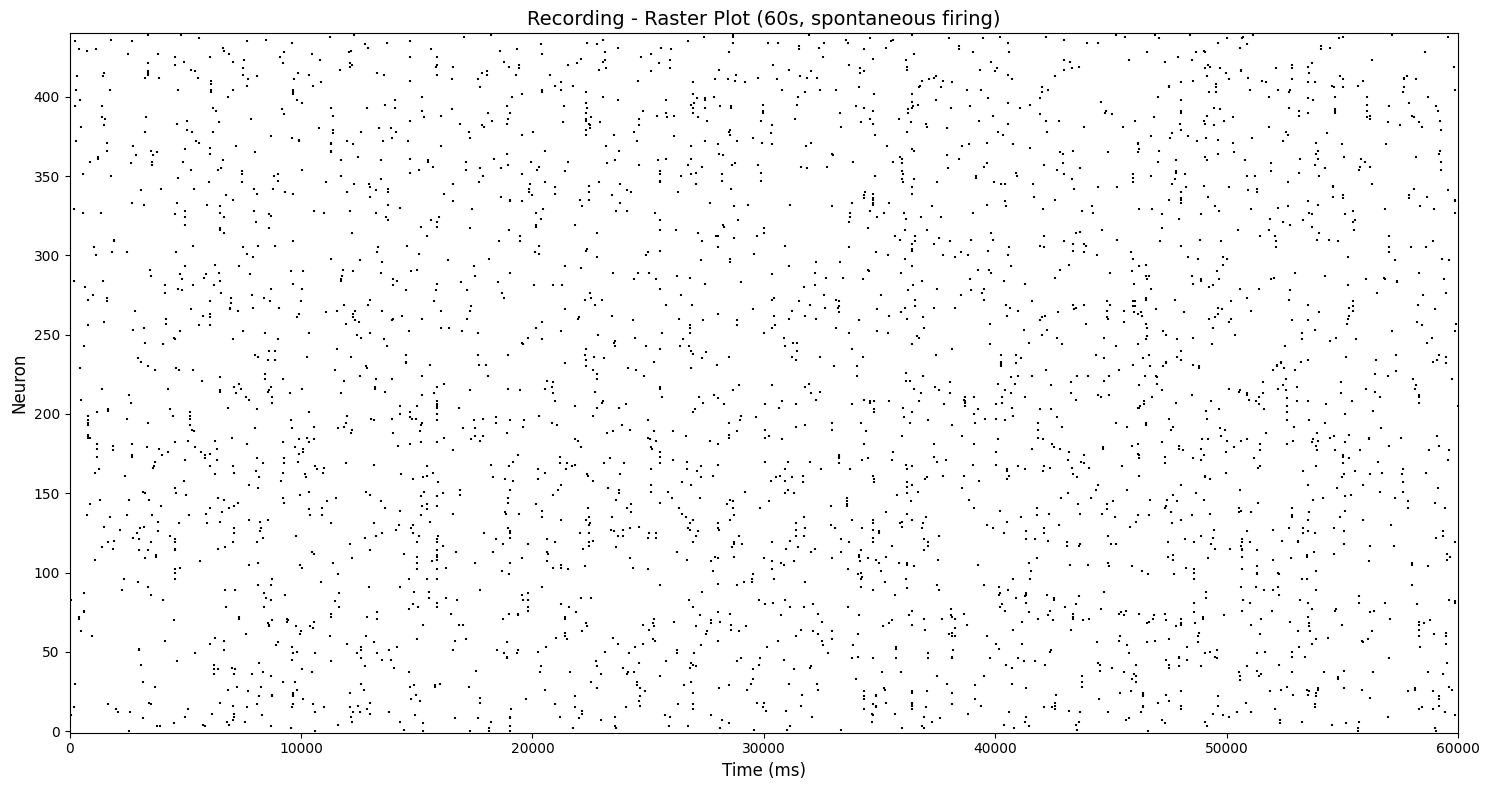


--- Generating Voltage Traces ---


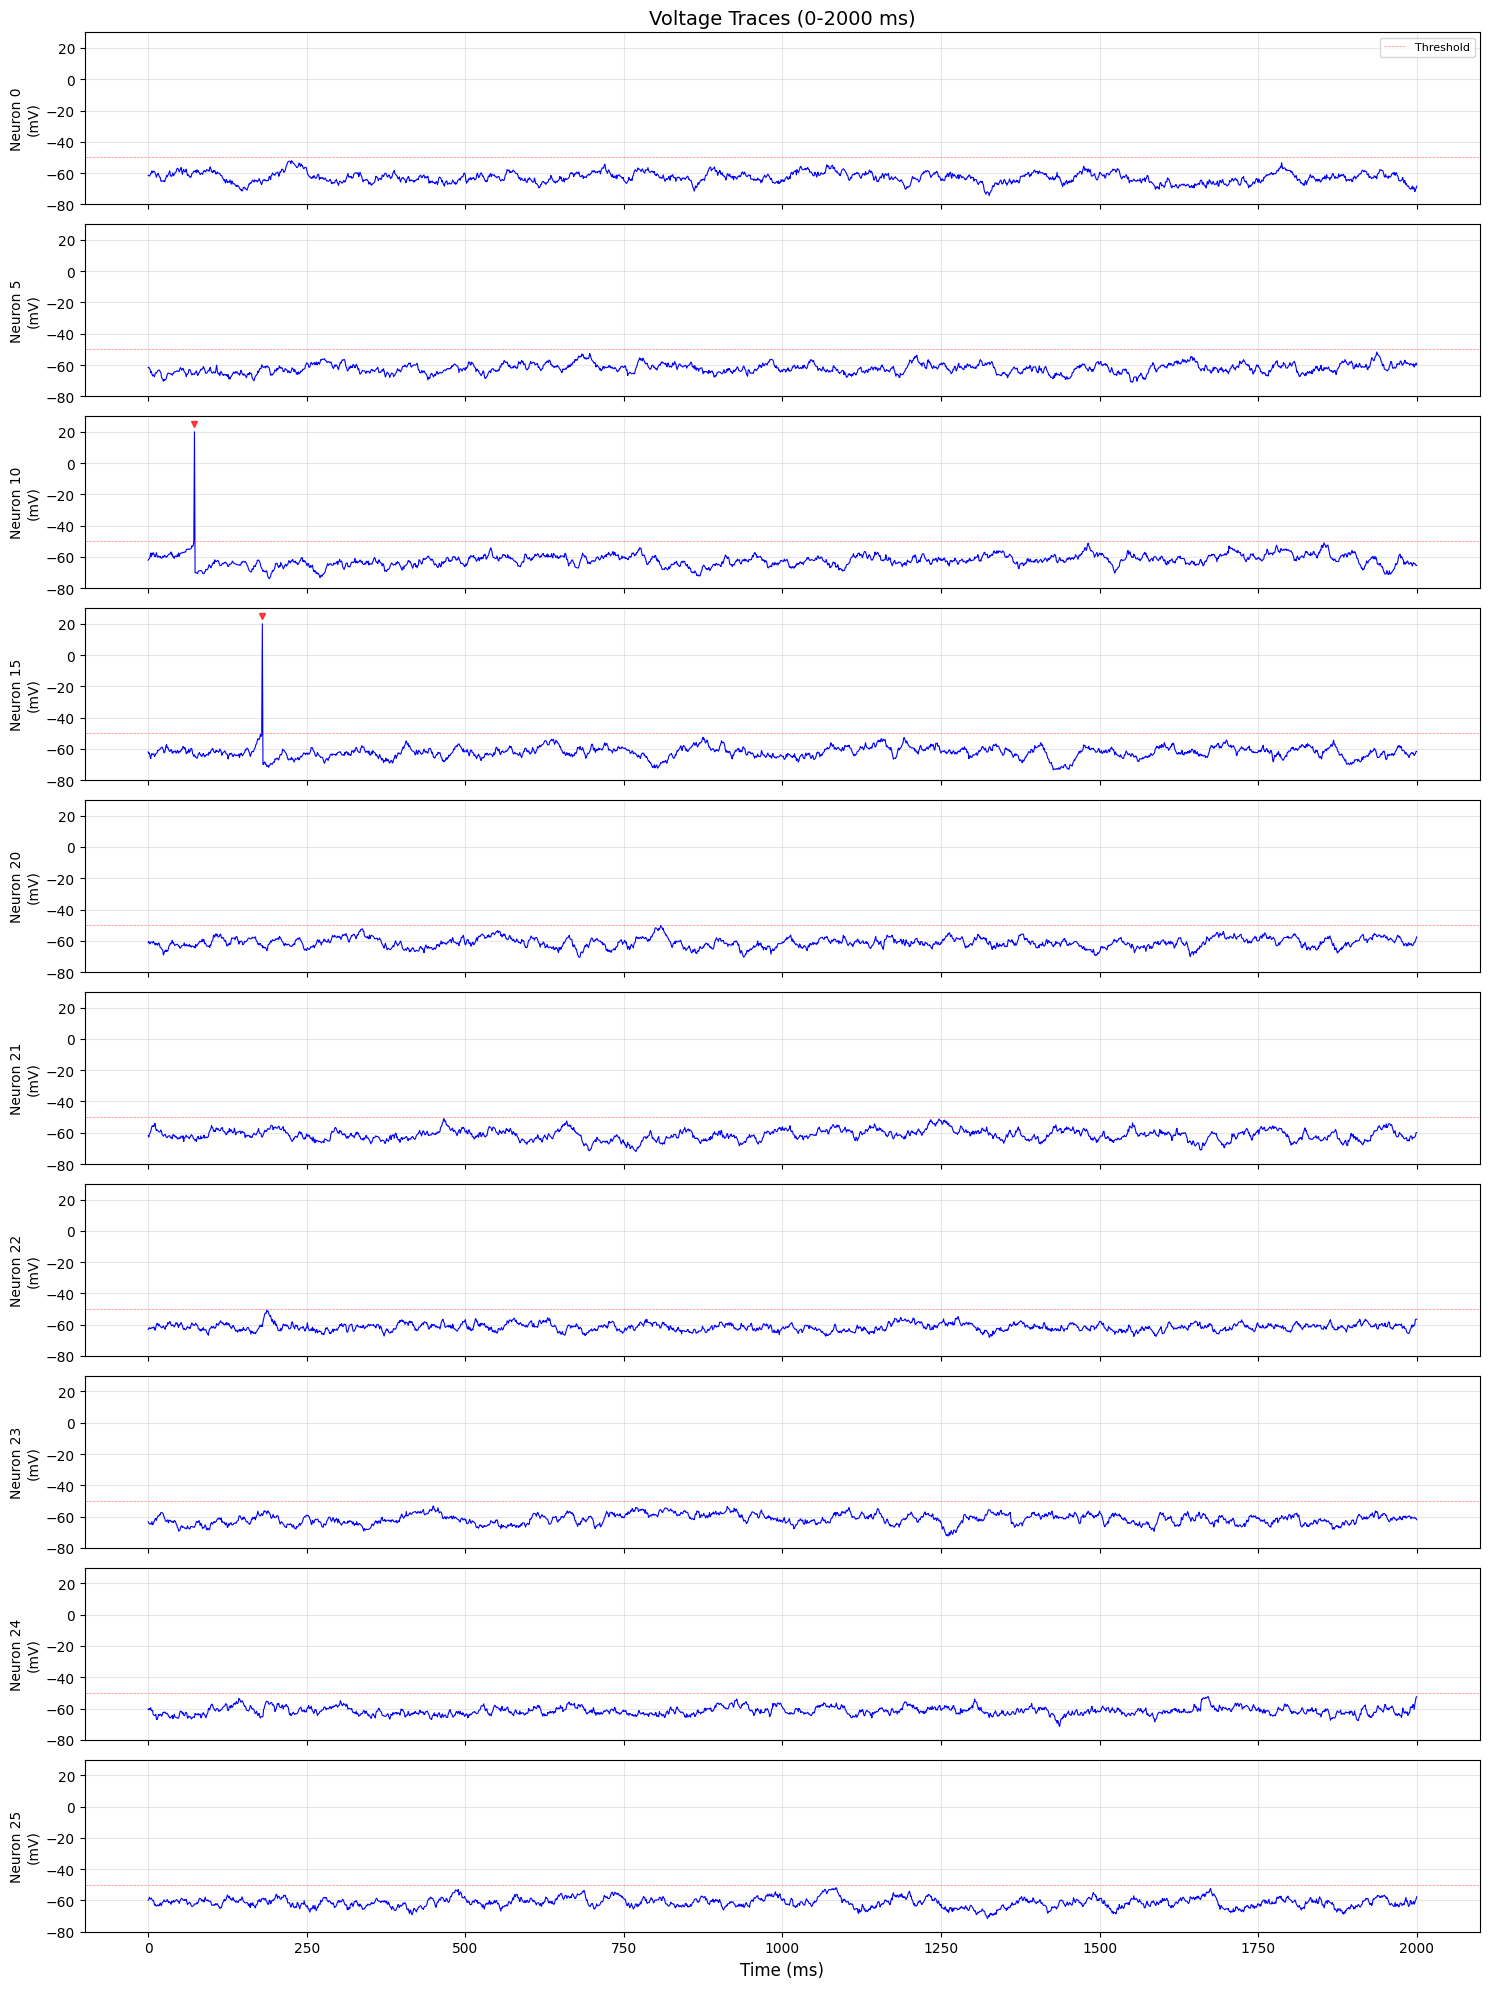


--- Generating Voltage Heatmap ---


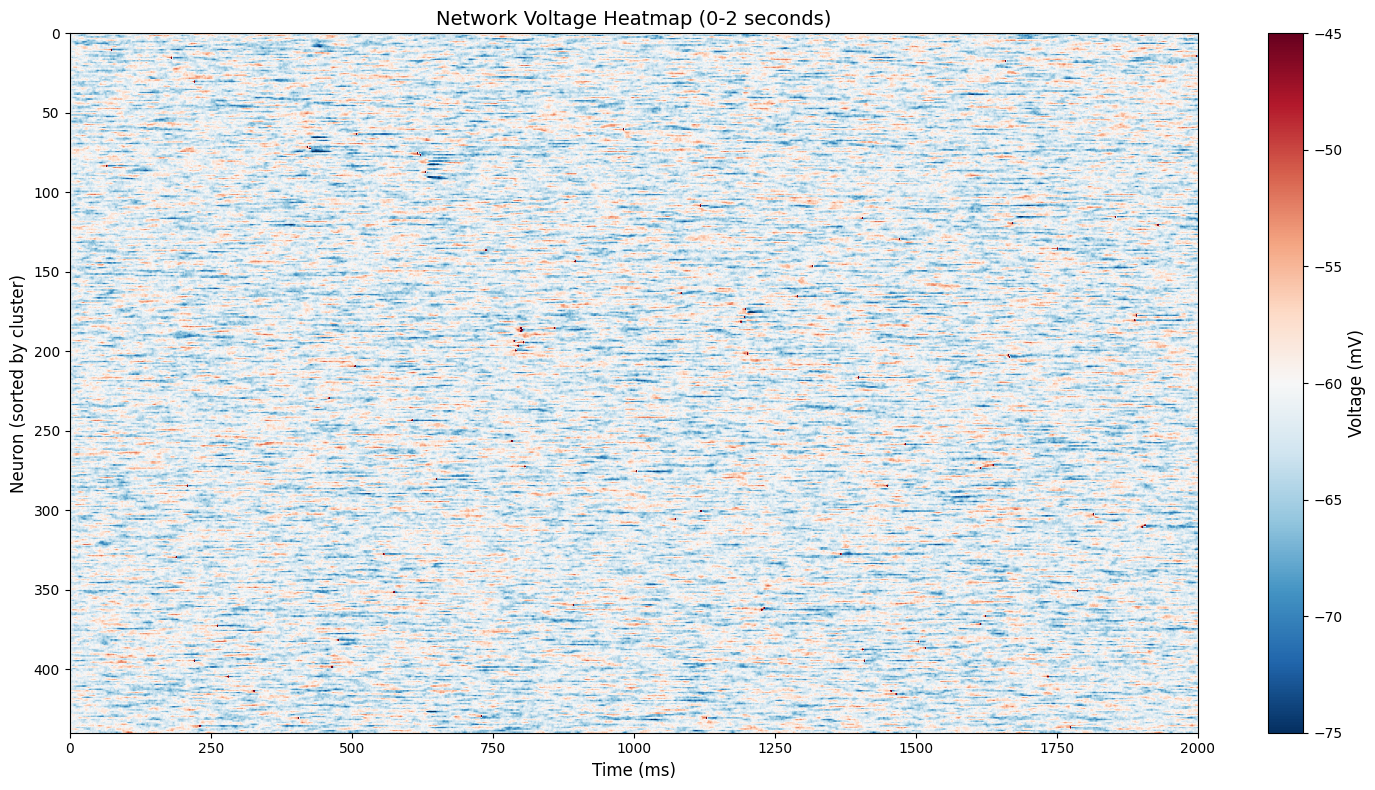


--- Generating Firing Rate Distribution ---


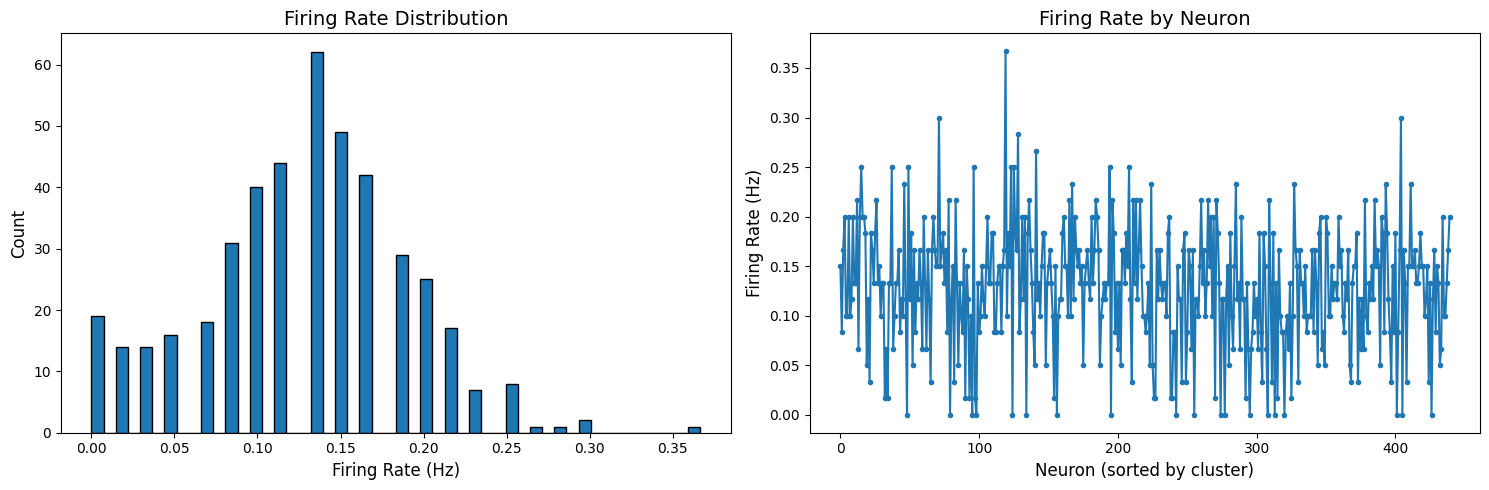


--- Generating Network Layout ---


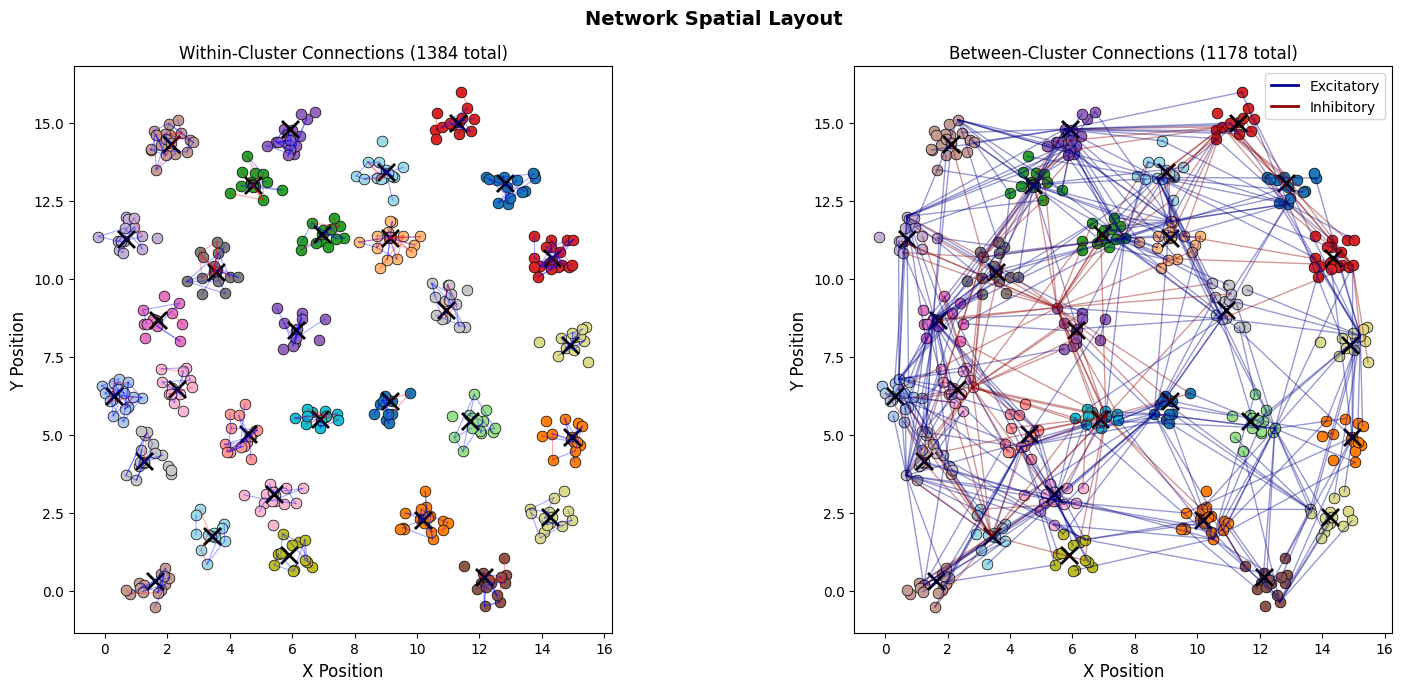


DATA SUMMARY
Session: 20260426_190829
Recording duration: 60.0 seconds
Number of neurons: 440
Number of clusters: 30
Total connections: 2562
Resampling frequency: 10.0 Hz
Total spikes: 3371
Mean firing rate: 0.13 Hz


In [ ]:
# Example: Load and visualize a single recording
# Find the most recent session folder

sessions = find_session_folders('LIF data')
if sessions:
    timestamp, session_dir, metadata_file = sessions[-1]  # Get most recent
    print(f"Loading session: {timestamp}")
    print(f"Session folder: {session_dir}")

    # Load session
    recordings, metadata = load_session_recordings(metadata_file)

    # Load network structure
    network_data = np.load(metadata['network_file'], allow_pickle=True)

    # Access data from first recording
    rec_data = recordings[0]

    # --- ORIGINAL SPIKE DATA (full precision) ---
    spike_times = rec_data['spike_times']
    cluster_spike_data = rec_data['cluster_spike_data']

    neuron_0_spikes = list(spike_times[0])
    print(f"Neuron 0 spiked {len(neuron_0_spikes)} times")
    if len(neuron_0_spikes) > 0:
        print(f"  First 10 spikes: {neuron_0_spikes[:10]}")

    # --- VOLTAGE TRACES (saved at the configured voltage_sample_rate; dt by default) ---
    voltage_data = None
    if 'voltage_traces' in rec_data:
        voltage_data = {
            'traces': rec_data['voltage_traces'],
            'times': rec_data['voltage_times'],
            'sample_rate': float(rec_data['voltage_sample_rate'])
        }
        print(f"Voltage traces: {voltage_data['traces'].shape[0]} neurons x {voltage_data['traces'].shape[1]} time points")

    # --- RESAMPLED DATA (saved acquisition bins) ---
    resampled_spikes = rec_data['resampled_spikes']
    resampled_times = rec_data['resampled_time_points']
    resampling_frequency = float(rec_data['resampling_frequency']) if 'resampling_frequency' in rec_data else float(metadata.get('target_freq', 10))

    spike_data_dict = {i: list(spikes) for i, spikes in enumerate(spike_times)}
    cluster_assignments = rec_data['resampled_cluster_assignments']

    recording_duration = float(metadata.get('recording_duration', rec_data['duration'] if 'duration' in rec_data else 60000))

    # --- BURST ONSET TIMES (stimulus timing, if present) ---
    burst_onset_times = None
    if 'burst_onset_times' in rec_data:
        burst_onset_times = rec_data['burst_onset_times']

    stimulation_enabled = burst_onset_times is not None and len(burst_onset_times) > 0
    if stimulation_enabled:
        print(f"Stimulus onsets loaded: {len(burst_onset_times)}")
    else:
        print("No stimulus onsets stored for this recording.")

    # ======================
    # VISUALIZATION
    # ======================

    # 1. Raster plot using original spike data
    print("\n--- Generating Raster Plot ---")
    activity_label = 'stimulus-driven' if stimulation_enabled else 'spontaneous firing'
    fig1 = plot_raster(
        spike_data_dict,
        cluster_assignments,
        recording_duration,
        f'Recording - Raster Plot ({recording_duration / 1000:.0f}s, {activity_label})'
    )
    if stimulation_enabled:
        ax = fig1.axes[0]
        for i, t in enumerate(burst_onset_times):
            ax.axvline(x=t, color='red', linewidth=0.8, alpha=0.5,
                       linestyle='--', label='Stimulus' if i == 0 else '')
        ax.legend(loc='upper right', fontsize=9)
    plt.show()

    # 2. Voltage traces for selected neurons (first 2 seconds)
    if voltage_data is not None:
        print("\n--- Generating Voltage Traces ---")
        neuron_ids_to_plot = [0, 5, 10, 15, 20, 21, 22, 23, 24, 25]
        fig2 = plot_voltage_traces(
            voltage_data,
            neuron_ids=neuron_ids_to_plot,
            time_range=(0, 2000),
            spike_data=spike_data_dict,
            title='Voltage Traces (0-2000 ms)'
        )
        plt.show()

    # 3. Voltage heatmap for all neurons (first 2 seconds)
    if voltage_data is not None:
        print("\n--- Generating Voltage Heatmap ---")
        fig3 = plot_voltage_heatmap(
            voltage_data,
            time_range=(0, 2000),
            cluster_assignments=cluster_assignments,
            title='Network Voltage Heatmap (0-2 seconds)'
        )
        plt.show()

    # 4. Firing rate distributions
    print("\n--- Generating Firing Rate Distribution ---")
    fig4 = plot_firing_rates(spike_data_dict, cluster_assignments, recording_duration)
    plt.show()

    # 5. Network spatial layout
    print("\n--- Generating Network Layout ---")
    network_positions = network_data['neuron_positions']
    network_cluster_info = {
        'cluster_centers': network_data['cluster_centers'],
        'cluster_neuron_groups': list(network_data['cluster_neuron_groups'])
    }
    network_connections = network_data['connections']
    fig5 = plot_network_positions(
        network_positions,
        network_cluster_info,
        network_connections,
        cluster_assignments=cluster_assignments,
        show_connections='sample',
        max_connections=500
    )
    plt.show()

    print("\n" + "=" * 60)
    print("DATA SUMMARY")
    print("=" * 60)
    print(f"Session: {timestamp}")
    print(f"Recording duration: {recording_duration / 1000:.1f} seconds")
    print(f"Number of neurons: {len(spike_times)}")
    print(f"Number of clusters: {len(network_cluster_info['cluster_neuron_groups'])}")
    print(f"Total connections: {len(network_connections)}")
    print(f"Resampling frequency: {resampling_frequency:.1f} Hz")
    total_spikes = sum(len(s) for s in spike_data_dict.values())
    print(f"Total spikes: {total_spikes}")
    mean_rate = total_spikes / len(spike_times) / (recording_duration / 1000)
    print(f"Mean firing rate: {mean_rate:.2f} Hz")
    print("=" * 60)

else:
    print("No session folders found. Run the simulation first (cell 28).")
    print("Sessions are saved in: LIF data/<timestamp>/")

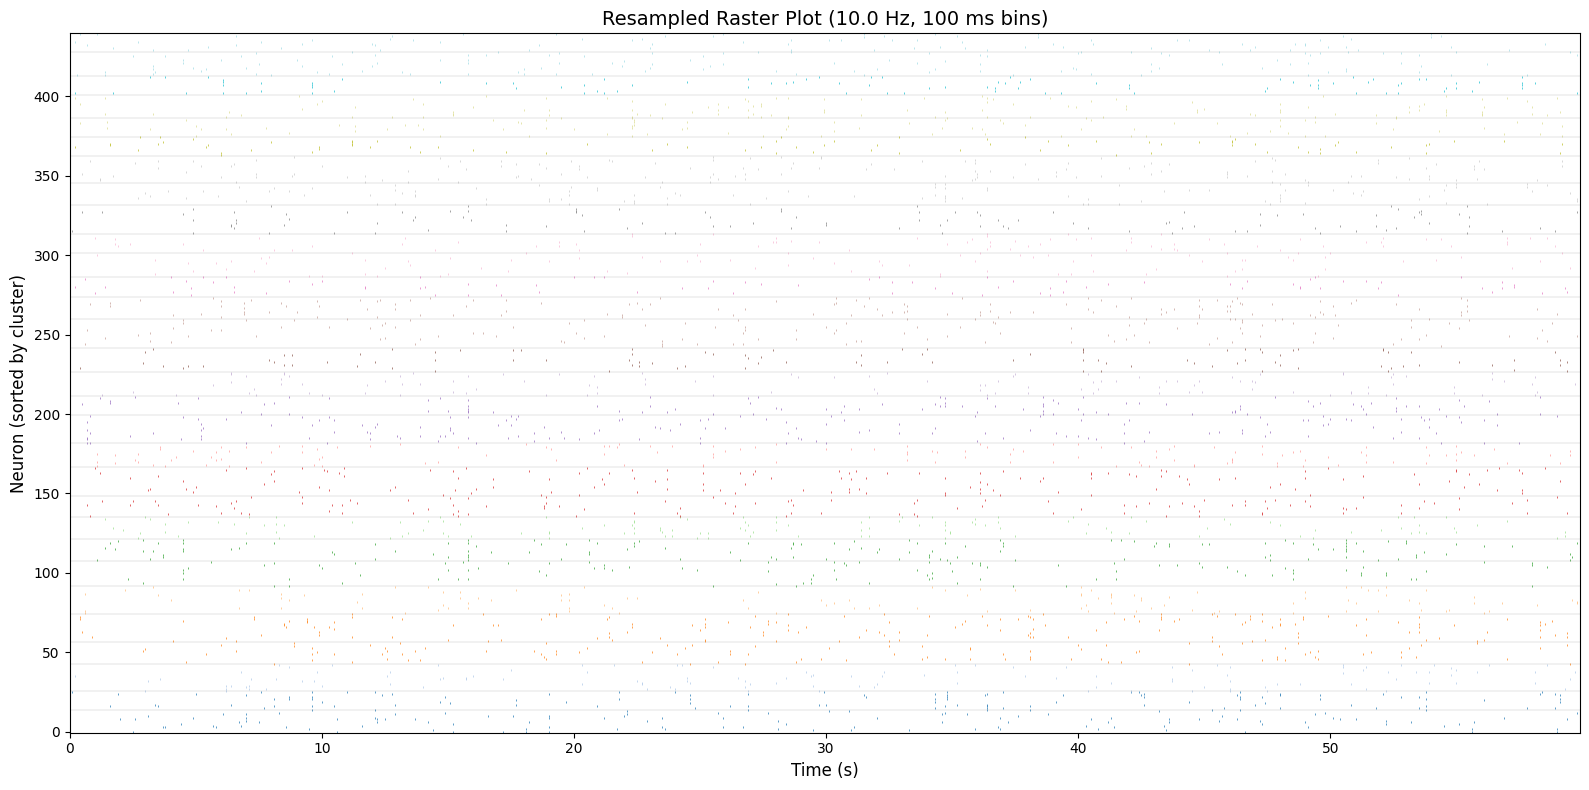


Resampled data: 440 neurons x 600 time bins
Time resolution: 100.0 ms (10.0 Hz)
Total active bins: 3371
Active neurons: 421/440
Mean active bins per neuron: 7.7


In [55]:
# ============================================================
# Resampled Raster Plot (saved binned data)
# ============================================================
# Uses resampled_spikes and cluster_assignments from the cell above

sorted_indices = np.argsort(cluster_assignments)
sorted_spikes = resampled_spikes[sorted_indices]
sorted_clusters = cluster_assignments[sorted_indices]

time_sec = resampled_times / 1000.0
bin_width_ms = float(resampled_times[1] - resampled_times[0]) if len(resampled_times) > 1 else 1000.0 / resampling_frequency
stimulation_enabled = burst_onset_times is not None and len(burst_onset_times) > 0

fig, ax = plt.subplots(figsize=(16, 8))

unique_clusters = np.unique(sorted_clusters)
cmap = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

# Plot each neuron's resampled spikes.
for neuron_idx in range(sorted_spikes.shape[0]):
    spike_times_idx = np.where(sorted_spikes[neuron_idx] == 1)[0]
    if len(spike_times_idx) > 0:
        cluster_id = sorted_clusters[neuron_idx]
        color = cmap[cluster_id % len(cmap)]
        ax.scatter(
            time_sec[spike_times_idx],
            np.full_like(spike_times_idx, neuron_idx, dtype=float),
            c=[color],
            s=1,
            marker='|',
            linewidths=0.5
        )

# Add cluster boundary lines.
for cluster_id in unique_clusters[:-1]:
    boundary = np.max(np.where(sorted_clusters == cluster_id)[0]) + 0.5
    ax.axhline(y=boundary, color='gray', linewidth=0.3, alpha=0.5)

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Neuron (sorted by cluster)', fontsize=12)
ax.set_title(
    f'Resampled Raster Plot ({resampling_frequency:.1f} Hz, {bin_width_ms:.0f} ms bins)',
    fontsize=14
)
ax.set_xlim(0, time_sec[-1] if len(time_sec) > 0 else 0)
ax.set_ylim(-0.5, sorted_spikes.shape[0] - 0.5)

if stimulation_enabled:
    for i, t in enumerate(burst_onset_times):
        ax.axvline(x=t / 1000.0, color='red', linewidth=0.8, alpha=0.5,
                   linestyle='--', label='Stimulus' if i == 0 else '')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

total_spike_bins = int(np.sum(sorted_spikes))
active_neurons = int(np.sum(np.any(sorted_spikes, axis=1)))
print(f'\nResampled data: {sorted_spikes.shape[0]} neurons x {sorted_spikes.shape[1]} time bins')
print(f'Time resolution: {bin_width_ms:.1f} ms ({resampling_frequency:.1f} Hz)')
print(f'Total active bins: {total_spike_bins}')
print(f'Active neurons: {active_neurons}/{sorted_spikes.shape[0]}')
print(f'Mean active bins per neuron: {total_spike_bins / sorted_spikes.shape[0]:.1f}')

SPIKE TRAIN ANALYSIS
Expected mode: spontaneous
Stimulus onsets available: 0

--------------------------------------------------
1. FIRING RATE ANALYSIS
--------------------------------------------------
Mean firing rate: 0.128 +/- 0.062 Hz
Median firing rate: 0.133 Hz
Range: 0.000 - 0.367 Hz
Active neurons: 421 / 440 (95.7%)
Silent neurons: 19

--------------------------------------------------
2. INTER-SPIKE INTERVAL (ISI) ANALYSIS
--------------------------------------------------
Mean ISI: 6265.66 ms
Median ISI: 4407.10 ms
Min ISI: 53.40 ms
ISI < 2 ms: 0 (0.000%)
Mean CV of ISI: 0.76 (about 1.0 is Poisson-like)

--------------------------------------------------
3. TEMPORAL DYNAMICS
--------------------------------------------------
Population rate (100 ms bins): mean=0.128 Hz, std=0.085 Hz
Max population rate: 0.636 Hz at t=15800 ms
Early activity: 0.119 Hz
Late activity: 0.131 Hz
Early/late delta: 0.012 Hz
Potential synchronized bins: 0 (threshold: 15.0% active neurons per 100 ms

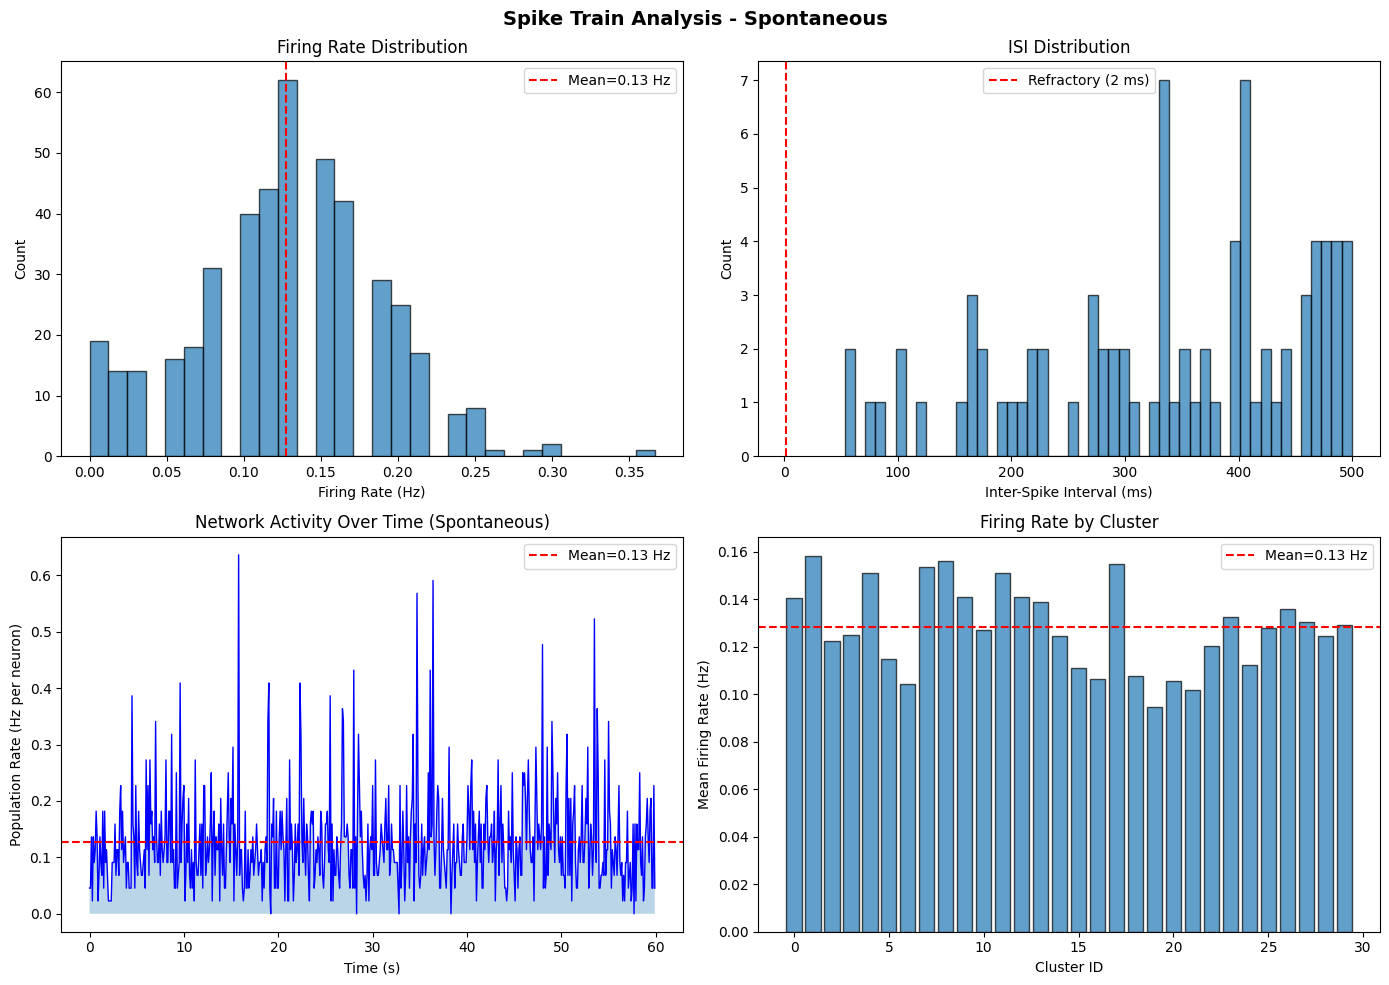

In [56]:
# ============================================================
# SPIKE TRAIN ANALYSIS - Model Quality Assessment
# ============================================================


def analyze_spike_trains(spike_data_dict, cluster_assignments, duration_ms,
                         connections=None, burst_onset_times=None,
                         expected_mode=None):
    """
    Comprehensive analysis of spike train properties.

    The expected regime is inferred automatically:
    - spontaneous: no stimulus onsets were saved
    - stimulus_driven: one or more stimulus onsets were saved
    """
    n_neurons = len(spike_data_dict)
    duration_s = duration_ms / 1000.0
    stimulus_enabled = burst_onset_times is not None and len(burst_onset_times) > 0

    if expected_mode is None:
        expected_mode = 'stimulus_driven' if stimulus_enabled else 'spontaneous'

    print("=" * 70)
    print("SPIKE TRAIN ANALYSIS")
    print("=" * 70)
    print(f"Expected mode: {expected_mode}")
    print(f"Stimulus onsets available: {len(burst_onset_times) if burst_onset_times is not None else 0}")

    # 1. FIRING RATE ANALYSIS
    print("\n" + "-" * 50)
    print("1. FIRING RATE ANALYSIS")
    print("-" * 50)

    firing_rates = []
    spike_counts = []
    for nid, spikes in spike_data_dict.items():
        n_spikes = len(spikes)
        spike_counts.append(n_spikes)
        firing_rates.append(n_spikes / duration_s)

    firing_rates = np.array(firing_rates)
    spike_counts = np.array(spike_counts)
    active_fraction = float(np.mean(firing_rates > 0)) if n_neurons > 0 else 0.0

    print(f"Mean firing rate: {np.mean(firing_rates):.3f} +/- {np.std(firing_rates):.3f} Hz")
    print(f"Median firing rate: {np.median(firing_rates):.3f} Hz")
    print(f"Range: {np.min(firing_rates):.3f} - {np.max(firing_rates):.3f} Hz")
    print(f"Active neurons: {np.sum(firing_rates > 0)} / {n_neurons} ({100 * active_fraction:.1f}%)")
    print(f"Silent neurons: {np.sum(firing_rates == 0)}")

    # 2. INTER-SPIKE INTERVAL (ISI) ANALYSIS
    print("\n" + "-" * 50)
    print("2. INTER-SPIKE INTERVAL (ISI) ANALYSIS")
    print("-" * 50)

    all_isis = []
    cv_isis = []
    for nid, spikes in spike_data_dict.items():
        if len(spikes) > 1:
            isis = np.diff(spikes)
            all_isis.extend(isis)
            if len(isis) > 1 and np.mean(isis) > 0:
                cv_isis.append(float(np.std(isis) / np.mean(isis)))

    all_isis = np.array(all_isis)
    refractory_violations = int(np.sum(all_isis < 2.0)) if len(all_isis) > 0 else 0

    if len(all_isis) > 0:
        print(f"Mean ISI: {np.mean(all_isis):.2f} ms")
        print(f"Median ISI: {np.median(all_isis):.2f} ms")
        print(f"Min ISI: {np.min(all_isis):.2f} ms")
        print(f"ISI < 2 ms: {refractory_violations} ({100 * refractory_violations / len(all_isis):.3f}%)")
        if cv_isis:
            print(f"Mean CV of ISI: {np.mean(cv_isis):.2f} (about 1.0 is Poisson-like)")
    else:
        print("Not enough spikes for ISI analysis")

    # 3. TEMPORAL DYNAMICS
    print("\n" + "-" * 50)
    print("3. TEMPORAL DYNAMICS")
    print("-" * 50)

    bin_size = 100  # ms
    n_bins = max(1, int(np.ceil(duration_ms / bin_size)))
    population_spike_counts = np.zeros(n_bins)
    active_neurons_per_bin = np.zeros(n_bins)

    for nid, spikes in spike_data_dict.items():
        if len(spikes) == 0:
            continue

        spike_bins = np.floor(np.asarray(spikes, dtype=float) / bin_size).astype(int)
        valid_spike_bins = spike_bins[(spike_bins >= 0) & (spike_bins < n_bins)]
        if valid_spike_bins.size == 0:
            continue

        np.add.at(population_spike_counts, valid_spike_bins, 1)
        active_neurons_per_bin[np.unique(valid_spike_bins)] += 1

    population_rate = population_spike_counts / (bin_size / 1000.0) / n_neurons
    active_fraction_per_bin = active_neurons_per_bin / n_neurons
    mean_population_rate = float(np.mean(population_rate))
    early_window = max(1, int(n_bins * 0.2))
    late_window = max(1, int(n_bins * 0.2))
    early_rate = float(np.mean(population_rate[:early_window]))
    late_rate = float(np.mean(population_rate[-late_window:]))
    rate_delta = late_rate - early_rate

    sync_threshold = max(
        float(np.mean(active_fraction_per_bin) + 4 * np.std(active_fraction_per_bin)),
        0.15
    )
    synchronized_bins = np.where(active_fraction_per_bin >= sync_threshold)[0]

    print(f"Population rate (100 ms bins): mean={mean_population_rate:.3f} Hz, std={np.std(population_rate):.3f} Hz")
    print(f"Max population rate: {np.max(population_rate):.3f} Hz at t={np.argmax(population_rate) * bin_size} ms")
    print(f"Early activity: {early_rate:.3f} Hz")
    print(f"Late activity: {late_rate:.3f} Hz")
    print(f"Early/late delta: {rate_delta:.3f} Hz")
    print(f"Potential synchronized bins: {len(synchronized_bins)} (threshold: {100 * sync_threshold:.1f}% active neurons per 100 ms bin)")

    # 4. CLUSTER-LEVEL ANALYSIS
    print("\n" + "-" * 50)
    print("4. CLUSTER-LEVEL ANALYSIS")
    print("-" * 50)

    unique_clusters = np.unique(cluster_assignments)
    cluster_rates = []
    for cid in unique_clusters:
        neuron_ids = np.where(cluster_assignments == cid)[0]
        rates = [firing_rates[nid] for nid in neuron_ids]
        cluster_rates.append(np.mean(rates) if len(rates) > 0 else 0.0)

    cluster_rates = np.array(cluster_rates)
    print(f"Number of clusters: {len(unique_clusters)}")
    print(f"Mean cluster firing rate: {np.mean(cluster_rates):.3f} +/- {np.std(cluster_rates):.3f} Hz")
    print(f"Cluster rate range: {np.min(cluster_rates):.3f} - {np.max(cluster_rates):.3f} Hz")
    print(f"Active clusters (>0.1 Hz mean): {np.sum(cluster_rates > 0.1)}/{len(unique_clusters)}")

    # 5. CONNECTIVITY ANALYSIS
    if connections is not None and len(connections) > 0:
        print("\n" + "-" * 50)
        print("5. CONNECTIVITY STATISTICS")
        print("-" * 50)

        n_exc = np.sum(connections[:, 3] == 'exc')
        n_inh = np.sum(connections[:, 3] == 'inh')

        print(f"Total connections: {len(connections)}")
        print(f"  Excitatory: {n_exc} ({100 * n_exc / len(connections):.1f}%)")
        print(f"  Inhibitory: {n_inh} ({100 * n_inh / len(connections):.1f}%)")
        print(f"Connection density: {100 * len(connections) / (n_neurons * (n_neurons - 1)):.2f}%")

        exc_weights = np.abs(connections[connections[:, 3] == 'exc', 2].astype(float))
        inh_weights = np.abs(connections[connections[:, 3] == 'inh', 2].astype(float))
        if len(exc_weights) > 0 and len(inh_weights) > 0:
            ei_ratio = np.sum(exc_weights) / np.sum(inh_weights)
            print(f"E/I weight ratio: {ei_ratio:.2f}")

    # 6. MODEL QUALITY VERDICT
    print("\n" + "=" * 70)
    print("MODEL QUALITY VERDICT")
    print("=" * 70)

    issues = []
    good_points = []
    mean_rate = float(np.mean(firing_rates)) if len(firing_rates) > 0 else 0.0
    stability_tolerance = max(0.25, 0.5 * max(mean_rate, 0.05))

    if expected_mode == 'spontaneous':
        if 0.05 <= mean_rate <= 2.0:
            good_points.append("Mean firing rate is within a sparse spontaneous range.")
        elif mean_rate < 0.05:
            issues.append("Mean firing rate is very low; the network may be too silent.")
        else:
            issues.append("Mean firing rate is high for spontaneous activity.")

        if active_fraction >= 0.30:
            good_points.append("A substantial fraction of neurons are participating.")
        else:
            issues.append("Too few neurons are active during the recording.")

        if len(synchronized_bins) == 0:
            good_points.append("No obvious population-wide synchronized bursts were detected.")
        else:
            issues.append(f"Detected {len(synchronized_bins)} potentially synchronized 100 ms bins; this suggests auto-bursting.")

        if abs(rate_delta) <= stability_tolerance:
            good_points.append("Early and late activity levels are reasonably stable.")
        else:
            issues.append("Activity level drifts substantially across the recording.")
    else:
        if len(synchronized_bins) > 0:
            good_points.append("Synchronized population events were detected.")
        else:
            issues.append("No synchronized population events were detected.")

        if stimulus_enabled:
            good_points.append("Stimulus onset metadata is present for alignment checks.")
        else:
            issues.append("Expected stimulus-driven mode, but no stimulus onsets were saved.")

    if refractory_violations == 0:
        good_points.append("No refractory period violations detected.")
    else:
        issues.append(f"Detected {refractory_violations} ISIs below 2 ms.")

    if cv_isis and np.mean(cv_isis) >= 0.5:
        good_points.append("Spike trains retain variability rather than becoming overly regular.")

    print("\nPOSITIVE ASPECTS:")
    if good_points:
        for point in good_points:
            print(f"  - {point}")
    else:
        print("  - None")

    print("\nISSUES TO ADDRESS:")
    if issues:
        for issue in issues:
            print(f"  - {issue}")
    else:
        print("  - No major issues detected.")

    print("\n" + "=" * 70)

    return {
        'expected_mode': expected_mode,
        'stimulus_enabled': stimulus_enabled,
        'burst_onset_times': burst_onset_times,
        'firing_rates': firing_rates,
        'all_isis': all_isis,
        'cv_isis': cv_isis,
        'population_rate': population_rate,
        'cluster_rates': cluster_rates,
        'active_fraction_per_bin': active_fraction_per_bin,
        'synchronized_bins': synchronized_bins,
        'sync_threshold': sync_threshold,
    }


# Run analysis on loaded data
if 'spike_data_dict' in dir() and spike_data_dict:
    analysis_results = analyze_spike_trains(
        spike_data_dict,
        cluster_assignments,
        recording_duration,
        network_connections,
        burst_onset_times=burst_onset_times
    )

    mode_title = analysis_results['expected_mode'].replace('_', ' ').title()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Firing rate histogram
    ax1 = axes[0, 0]
    ax1.hist(analysis_results['firing_rates'], bins=30, edgecolor='black', alpha=0.7)
    ax1.axvline(np.mean(analysis_results['firing_rates']), color='r', linestyle='--',
                label=f"Mean={np.mean(analysis_results['firing_rates']):.2f} Hz")
    ax1.set_xlabel('Firing Rate (Hz)')
    ax1.set_ylabel('Count')
    ax1.set_title('Firing Rate Distribution')
    ax1.legend()

    # 2. ISI histogram
    ax2 = axes[0, 1]
    if len(analysis_results['all_isis']) > 0:
        isis_to_plot = analysis_results['all_isis'][analysis_results['all_isis'] < 500]
        ax2.hist(isis_to_plot, bins=50, edgecolor='black', alpha=0.7)
        ax2.axvline(2, color='r', linestyle='--', label='Refractory (2 ms)')
        ax2.set_xlabel('Inter-Spike Interval (ms)')
        ax2.set_ylabel('Count')
        ax2.set_title('ISI Distribution')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Not enough spikes', ha='center', va='center', transform=ax2.transAxes)

    # 3. Population rate over time
    ax3 = axes[1, 0]
    time_bins = np.arange(len(analysis_results['population_rate'])) * 100  # ms
    ax3.plot(time_bins / 1000.0, analysis_results['population_rate'], 'b-', linewidth=1)
    ax3.fill_between(time_bins / 1000.0, analysis_results['population_rate'], alpha=0.3)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Population Rate (Hz per neuron)')
    ax3.set_title(f'Network Activity Over Time ({mode_title})')
    ax3.axhline(np.mean(analysis_results['population_rate']), color='r', linestyle='--',
                label=f"Mean={np.mean(analysis_results['population_rate']):.2f} Hz")
    if analysis_results['stimulus_enabled']:
        for i, t in enumerate(analysis_results['burst_onset_times']):
            ax3.axvline(t / 1000.0, color='k', linewidth=0.8, alpha=0.4,
                        linestyle='--', label='Stimulus' if i == 0 else '')
    ax3.legend()

    # 4. Cluster firing rates
    ax4 = axes[1, 1]
    ax4.bar(range(len(analysis_results['cluster_rates'])), analysis_results['cluster_rates'],
            edgecolor='black', alpha=0.7)
    ax4.axhline(np.mean(analysis_results['cluster_rates']), color='r', linestyle='--',
                label=f"Mean={np.mean(analysis_results['cluster_rates']):.2f} Hz")
    ax4.set_xlabel('Cluster ID')
    ax4.set_ylabel('Mean Firing Rate (Hz)')
    ax4.set_title('Firing Rate by Cluster')
    ax4.legend()

    plt.suptitle(f'Spike Train Analysis - {mode_title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No spike data loaded. Run the visualization cell first.')

## Part 12: Hub Neuron Visualization and Validation

Loaded 30 hub neurons from saved network data
Hub parameters: fraction=0.1, between_prob=0.25, weight_scale=1.5

--- Hub Network Topology ---


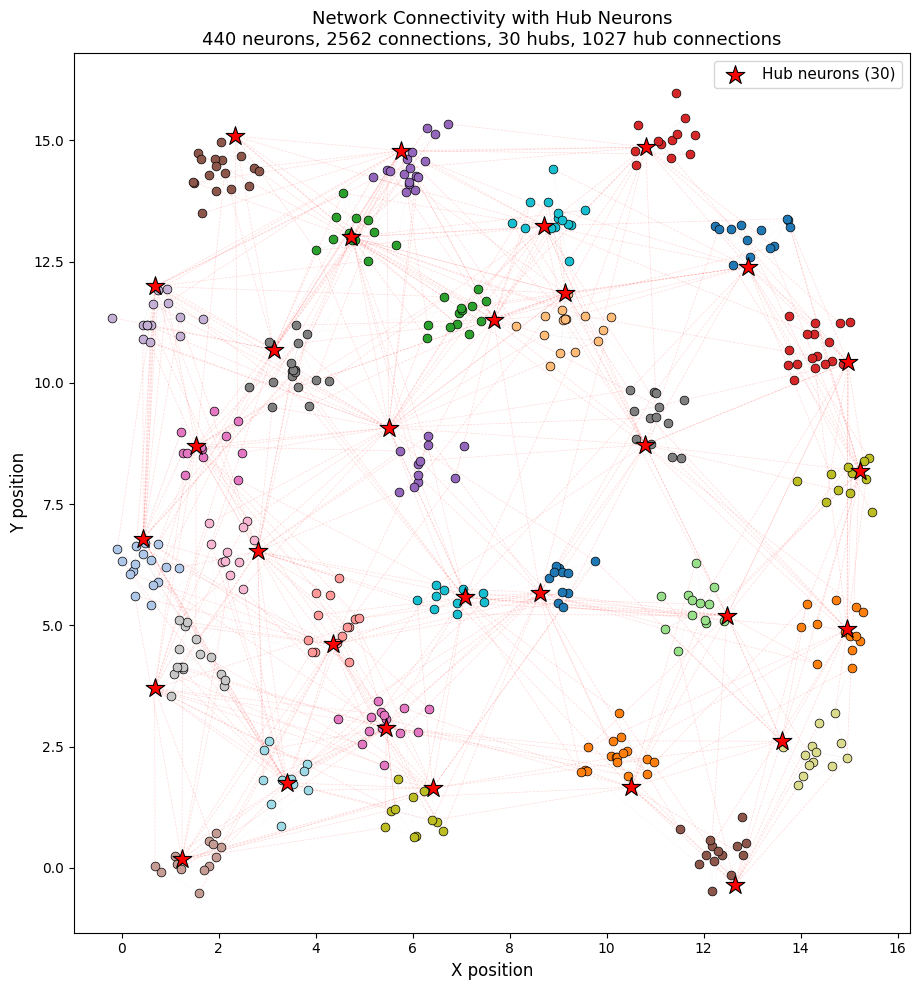


--- Hub Structure Validation ---
HUB NEURON VALIDATION
Total neurons: 440
Hub neurons: 30 (6.8%)
Hub fraction setting: 0.1

Hub mean total degree:     44.5 +/- 11.6
Non-hub mean total degree: 9.2 +/- 3.3
Degree ratio (hub/non-hub): 4.81x

Hub mean out-degree: 37.0 | Non-hub: 3.5
Hub mean in-degree:  7.5 | Non-hub: 5.7

Hub inter-cluster fraction:     91.3% (1013/1109)
Non-hub inter-cluster fraction: 11.4% (165/1453)

  [PASS] Degree ratio >= 2x
  [PASS] Hub between-cluster fraction > non-hub
  [PASS] Hub count > 0


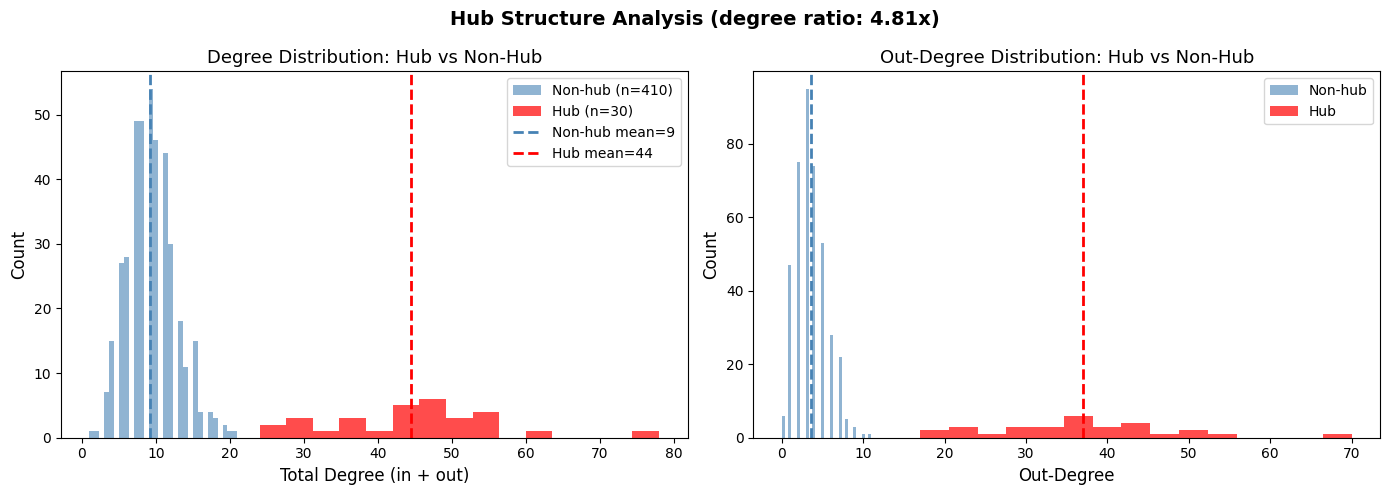

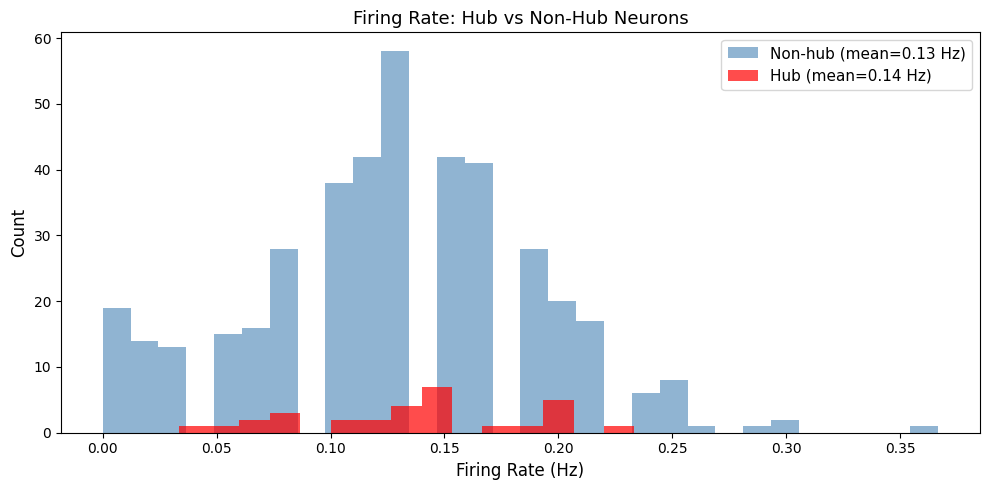


Hub neuron mean firing rate: 0.14 Hz
Non-hub neuron mean firing rate: 0.13 Hz
Firing rate ratio (hub/non-hub): 1.07x


In [57]:
# ============================================================
# HUB NEURON VISUALIZATION AND STRUCTURE VALIDATION
# ============================================================
# Uses network data loaded in Part 11 (cell above)

if 'network_data' in dir() and network_data is not None:
    # Reconstruct cluster_info with hub data from saved network
    hub_cluster_info = {
        'cluster_centers': network_data['cluster_centers'],
        'cluster_sizes': network_data['cluster_sizes'],
        'cluster_assignments': network_data['cluster_assignments'],
        'cluster_neuron_groups': list(network_data['cluster_neuron_groups']),
    }

    # Load hub data if available
    if 'hub_neuron_ids' in network_data:
        hub_ids = list(network_data['hub_neuron_ids'])
        hub_cluster_info['hub_neuron_ids'] = hub_ids
        hub_cluster_info['hub_fraction'] = float(network_data.get('hub_fraction', 0.1))
        hub_cluster_info['hub_between_prob'] = float(network_data.get('hub_between_prob', 0.4))
        hub_cluster_info['hub_weight_scale'] = float(network_data.get('hub_weight_scale', 1.5))
        hub_cluster_info['hub_reciprocal_factor'] = float(network_data.get('hub_reciprocal_factor', 2.0))
        hub_cluster_info['n_hub_connections'] = int(network_data.get('n_hub_connections', 0))

        print(f"Loaded {len(hub_ids)} hub neurons from saved network data")
        print(f"Hub parameters: fraction={hub_cluster_info['hub_fraction']}, "
              f"between_prob={hub_cluster_info['hub_between_prob']}, "
              f"weight_scale={hub_cluster_info['hub_weight_scale']}")
        print()

        # --- 1. Hub Network Topology Plot ---
        print("--- Hub Network Topology ---")
        network_positions = network_data['neuron_positions']
        network_connections = network_data['connections']

        fig_hub, ax_hub = plot_hub_network(
            network_positions, network_connections, hub_cluster_info
        )
        plt.show()

        # --- 2. Hub Structure Validation ---
        print("\n--- Hub Structure Validation ---")
        n_neurons = len(network_positions)
        hub_stats = validate_hub_structure(
            network_connections, hub_cluster_info, n_neurons
        )

        # --- 3. Hub vs Non-Hub Degree Distribution ---
        if hub_stats is not None:
            fig_deg, axes_deg = plt.subplots(1, 2, figsize=(14, 5))

            # Degree histogram comparison
            ax1 = axes_deg[0]
            ax1.hist(hub_stats['non_hub_degrees'], bins=30, alpha=0.6,
                     label=f"Non-hub (n={len(hub_stats['non_hub_degrees'])})", color='steelblue')
            ax1.hist(hub_stats['hub_degrees'], bins=15, alpha=0.7,
                     label=f"Hub (n={len(hub_stats['hub_degrees'])})", color='red')
            ax1.axvline(np.mean(hub_stats['non_hub_degrees']), color='steelblue',
                       linestyle='--', linewidth=2, label=f"Non-hub mean={np.mean(hub_stats['non_hub_degrees']):.0f}")
            ax1.axvline(np.mean(hub_stats['hub_degrees']), color='red',
                       linestyle='--', linewidth=2, label=f"Hub mean={np.mean(hub_stats['hub_degrees']):.0f}")
            ax1.set_xlabel('Total Degree (in + out)', fontsize=12)
            ax1.set_ylabel('Count', fontsize=12)
            ax1.set_title('Degree Distribution: Hub vs Non-Hub', fontsize=13)
            ax1.legend(fontsize=10)

            # Out-degree comparison
            ax2 = axes_deg[1]
            ax2.hist(hub_stats['non_hub_out_degree'], bins=30, alpha=0.6,
                     label=f"Non-hub", color='steelblue')
            ax2.hist(hub_stats['hub_out_degree'], bins=15, alpha=0.7,
                     label=f"Hub", color='red')
            ax2.axvline(np.mean(hub_stats['non_hub_out_degree']), color='steelblue',
                       linestyle='--', linewidth=2)
            ax2.axvline(np.mean(hub_stats['hub_out_degree']), color='red',
                       linestyle='--', linewidth=2)
            ax2.set_xlabel('Out-Degree', fontsize=12)
            ax2.set_ylabel('Count', fontsize=12)
            ax2.set_title('Out-Degree Distribution: Hub vs Non-Hub', fontsize=13)
            ax2.legend(fontsize=10)

            plt.suptitle(f'Hub Structure Analysis (degree ratio: {hub_stats["degree_ratio"]:.2f}x)',
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

        # --- 4. Hub Neuron Firing Rate Comparison ---
        if 'spike_data_dict' in dir() and spike_data_dict:
            hub_set = set(hub_ids)
            hub_rates = []
            non_hub_rates = []
            duration_s = recording_duration / 1000.0

            for nid, spikes in spike_data_dict.items():
                rate = len(spikes) / duration_s
                if nid in hub_set:
                    hub_rates.append(rate)
                else:
                    non_hub_rates.append(rate)

            fig_rates, ax_rates = plt.subplots(figsize=(10, 5))
            ax_rates.hist(non_hub_rates, bins=30, alpha=0.6,
                         label=f'Non-hub (mean={np.mean(non_hub_rates):.2f} Hz)', color='steelblue')
            ax_rates.hist(hub_rates, bins=15, alpha=0.7,
                         label=f'Hub (mean={np.mean(hub_rates):.2f} Hz)', color='red')
            ax_rates.set_xlabel('Firing Rate (Hz)', fontsize=12)
            ax_rates.set_ylabel('Count', fontsize=12)
            ax_rates.set_title('Firing Rate: Hub vs Non-Hub Neurons', fontsize=13)
            ax_rates.legend(fontsize=11)
            plt.tight_layout()
            plt.show()

            print(f"\nHub neuron mean firing rate: {np.mean(hub_rates):.2f} Hz")
            print(f"Non-hub neuron mean firing rate: {np.mean(non_hub_rates):.2f} Hz")
            print(f"Firing rate ratio (hub/non-hub): {np.mean(hub_rates)/np.mean(non_hub_rates):.2f}x"
                  if np.mean(non_hub_rates) > 0 else "Non-hub rate is 0")
    else:
        print("No hub neuron data found in saved network.")
        print("Re-run the simulation with hub_fraction > 0 to generate hub data.")
else:
    print("No network data loaded. Run the data loading cell (Part 11) first.")
